In [2]:
import numpy as np 
import time 
from scipy.special import zeta
import math 
import matplotlib.pyplot as plt 
import time 
import random 
import sys 
import os 
import warnings 
warnings.filterwarnings("ignore")

# List containing 10 000 prime numbers 
- List of 10 000 primes Retrieved from https://gist.github.com/B45i/652e54adafa3aabed7518c6809ac24c0
- Erathostenes sieve algorithm (For ```generate_primes``` function):
https://en.wikipedia.org/wiki/Sieve_of_Eratosthenes
1 and 0 are not primes
For each integer from 2 to sqrt(n), if the integer is prime, then mark all of its multiples as composites.


In [4]:
primes = np.array([ 2, 3, 5, 7, 11, 13, 17, 19, 23, 29,
31, 37, 41, 43, 47, 53, 59, 61, 67, 71,
73, 79, 83, 89, 97, 101, 103, 107, 109, 113,
127, 131, 137, 139, 149, 151, 157, 163, 167, 173,
179, 181, 191, 193, 197, 199, 211, 223, 227, 229,
233, 239, 241, 251, 257, 263, 269, 271, 277, 281,
283, 293, 307, 311, 313, 317, 331, 337, 347, 349,
353, 359, 367, 373, 379, 383, 389, 397, 401, 409,
419, 421, 431, 433, 439, 443, 449, 457, 461, 463,
467, 479, 487, 491, 499, 503, 509, 521, 523, 541,
547, 557, 563, 569, 571, 577, 587, 593, 599, 601,
607, 613, 617, 619, 631, 641, 643, 647, 653, 659,
661, 673, 677, 683, 691, 701, 709, 719, 727, 733,
739, 743, 751, 757, 761, 769, 773, 787, 797, 809,
811, 821, 823, 827, 829, 839, 853, 857, 859, 863,
877, 881, 883, 887, 907, 911, 919, 929, 937, 941,
947, 953, 967, 971, 977, 983, 991, 997, 1009, 1013,
1019, 1021, 1031, 1033, 1039, 1049, 1051, 1061, 1063, 1069,
1087, 1091, 1093, 1097, 1103, 1109, 1117, 1123, 1129, 1151,
1153, 1163, 1171, 1181, 1187, 1193, 1201, 1213, 1217, 1223,
1229, 1231, 1237, 1249, 1259, 1277, 1279, 1283, 1289, 1291,
1297, 1301, 1303, 1307, 1319, 1321, 1327, 1361, 1367, 1373,
1381, 1399, 1409, 1423, 1427, 1429, 1433, 1439, 1447, 1451,
1453, 1459, 1471, 1481, 1483, 1487, 1489, 1493, 1499, 1511,
1523, 1531, 1543, 1549, 1553, 1559, 1567, 1571, 1579, 1583,
1597, 1601, 1607, 1609, 1613, 1619, 1621, 1627, 1637, 1657,
1663, 1667, 1669, 1693, 1697, 1699, 1709, 1721, 1723, 1733,
1741, 1747, 1753, 1759, 1777, 1783, 1787, 1789, 1801, 1811,
1823, 1831, 1847, 1861, 1867, 1871, 1873, 1877, 1879, 1889,
1901, 1907, 1913, 1931, 1933, 1949, 1951, 1973, 1979, 1987,
1993, 1997, 1999, 2003, 2011, 2017, 2027, 2029, 2039, 2053,
2063, 2069, 2081, 2083, 2087, 2089, 2099, 2111, 2113, 2129,
2131, 2137, 2141, 2143, 2153, 2161, 2179, 2203, 2207, 2213,
2221, 2237, 2239, 2243, 2251, 2267, 2269, 2273, 2281, 2287,
2293, 2297, 2309, 2311, 2333, 2339, 2341, 2347, 2351, 2357,
2371, 2377, 2381, 2383, 2389, 2393, 2399, 2411, 2417, 2423,
2437, 2441, 2447, 2459, 2467, 2473, 2477, 2503, 2521, 2531,
2539, 2543, 2549, 2551, 2557, 2579, 2591, 2593, 2609, 2617,
2621, 2633, 2647, 2657, 2659, 2663, 2671, 2677, 2683, 2687,
2689, 2693, 2699, 2707, 2711, 2713, 2719, 2729, 2731, 2741,
2749, 2753, 2767, 2777, 2789, 2791, 2797, 2801, 2803, 2819,
2833, 2837, 2843, 2851, 2857, 2861, 2879, 2887, 2897, 2903,
2909, 2917, 2927, 2939, 2953, 2957, 2963, 2969, 2971, 2999,
3001, 3011, 3019, 3023, 3037, 3041, 3049, 3061, 3067, 3079,
3083, 3089, 3109, 3119, 3121, 3137, 3163, 3167, 3169, 3181,
3187, 3191, 3203, 3209, 3217, 3221, 3229, 3251, 3253, 3257,
3259, 3271, 3299, 3301, 3307, 3313, 3319, 3323, 3329, 3331,
3343, 3347, 3359, 3361, 3371, 3373, 3389, 3391, 3407, 3413,
3433, 3449, 3457, 3461, 3463, 3467, 3469, 3491, 3499, 3511,
3517, 3527, 3529, 3533, 3539, 3541, 3547, 3557, 3559, 3571,
3581, 3583, 3593, 3607, 3613, 3617, 3623, 3631, 3637, 3643,
3659, 3671, 3673, 3677, 3691, 3697, 3701, 3709, 3719, 3727,
3733, 3739, 3761, 3767, 3769, 3779, 3793, 3797, 3803, 3821,
3823, 3833, 3847, 3851, 3853, 3863, 3877, 3881, 3889, 3907,
3911, 3917, 3919, 3923, 3929, 3931, 3943, 3947, 3967, 3989,
4001, 4003, 4007, 4013, 4019, 4021, 4027, 4049, 4051, 4057,
4073, 4079, 4091, 4093, 4099, 4111, 4127, 4129, 4133, 4139,
4153, 4157, 4159, 4177, 4201, 4211, 4217, 4219, 4229, 4231,
4241, 4243, 4253, 4259, 4261, 4271, 4273, 4283, 4289, 4297,
4327, 4337, 4339, 4349, 4357, 4363, 4373, 4391, 4397, 4409,
4421, 4423, 4441, 4447, 4451, 4457, 4463, 4481, 4483, 4493,
4507, 4513, 4517, 4519, 4523, 4547, 4549, 4561, 4567, 4583,
4591, 4597, 4603, 4621, 4637, 4639, 4643, 4649, 4651, 4657,
4663, 4673, 4679, 4691, 4703, 4721, 4723, 4729, 4733, 4751,
4759, 4783, 4787, 4789, 4793, 4799, 4801, 4813, 4817, 4831,
4861, 4871, 4877, 4889, 4903, 4909, 4919, 4931, 4933, 4937,
4943, 4951, 4957, 4967, 4969, 4973, 4987, 4993, 4999, 5003,
5009, 5011, 5021, 5023, 5039, 5051, 5059, 5077, 5081, 5087,
5099, 5101, 5107, 5113, 5119, 5147, 5153, 5167, 5171, 5179,
5189, 5197, 5209, 5227, 5231, 5233, 5237, 5261, 5273, 5279,
5281, 5297, 5303, 5309, 5323, 5333, 5347, 5351, 5381, 5387,
5393, 5399, 5407, 5413, 5417, 5419, 5431, 5437, 5441, 5443,
5449, 5471, 5477, 5479, 5483, 5501, 5503, 5507, 5519, 5521,
5527, 5531, 5557, 5563, 5569, 5573, 5581, 5591, 5623, 5639,
5641, 5647, 5651, 5653, 5657, 5659, 5669, 5683, 5689, 5693,
5701, 5711, 5717, 5737, 5741, 5743, 5749, 5779, 5783, 5791,
5801, 5807, 5813, 5821, 5827, 5839, 5843, 5849, 5851, 5857,
5861, 5867, 5869, 5879, 5881, 5897, 5903, 5923, 5927, 5939,
5953, 5981, 5987, 6007, 6011, 6029, 6037, 6043, 6047, 6053,
6067, 6073, 6079, 6089, 6091, 6101, 6113, 6121, 6131, 6133,
6143, 6151, 6163, 6173, 6197, 6199, 6203, 6211, 6217, 6221,
6229, 6247, 6257, 6263, 6269, 6271, 6277, 6287, 6299, 6301,
6311, 6317, 6323, 6329, 6337, 6343, 6353, 6359, 6361, 6367,
6373, 6379, 6389, 6397, 6421, 6427, 6449, 6451, 6469, 6473,
6481, 6491, 6521, 6529, 6547, 6551, 6553, 6563, 6569, 6571,
6577, 6581, 6599, 6607, 6619, 6637, 6653, 6659, 6661, 6673,
6679, 6689, 6691, 6701, 6703, 6709, 6719, 6733, 6737, 6761,
6763, 6779, 6781, 6791, 6793, 6803, 6823, 6827, 6829, 6833,
6841, 6857, 6863, 6869, 6871, 6883, 6899, 6907, 6911, 6917,
6947, 6949, 6959, 6961, 6967, 6971, 6977, 6983, 6991, 6997,
7001, 7013, 7019, 7027, 7039, 7043, 7057, 7069, 7079, 7103,
7109, 7121, 7127, 7129, 7151, 7159, 7177, 7187, 7193, 7207,
7211, 7213, 7219, 7229, 7237, 7243, 7247, 7253, 7283, 7297,
7307, 7309, 7321, 7331, 7333, 7349, 7351, 7369, 7393, 7411,
7417, 7433, 7451, 7457, 7459, 7477, 7481, 7487, 7489, 7499,
7507, 7517, 7523, 7529, 7537, 7541, 7547, 7549, 7559, 7561,
7573, 7577, 7583, 7589, 7591, 7603, 7607, 7621, 7639, 7643,
7649, 7669, 7673, 7681, 7687, 7691, 7699, 7703, 7717, 7723,
7727, 7741, 7753, 7757, 7759, 7789, 7793, 7817, 7823, 7829,
7841, 7853, 7867, 7873, 7877, 7879, 7883, 7901, 7907, 7919,
7927, 7933, 7937, 7949, 7951, 7963, 7993, 8009, 8011, 8017,
8039, 8053, 8059, 8069, 8081, 8087, 8089, 8093, 8101, 8111,
8117, 8123, 8147, 8161, 8167, 8171, 8179, 8191, 8209, 8219,
8221, 8231, 8233, 8237, 8243, 8263, 8269, 8273, 8287, 8291,
8293, 8297, 8311, 8317, 8329, 8353, 8363, 8369, 8377, 8387,
8389, 8419, 8423, 8429, 8431, 8443, 8447, 8461, 8467, 8501,
8513, 8521, 8527, 8537, 8539, 8543, 8563, 8573, 8581, 8597,
8599, 8609, 8623, 8627, 8629, 8641, 8647, 8663, 8669, 8677,
8681, 8689, 8693, 8699, 8707, 8713, 8719, 8731, 8737, 8741,
8747, 8753, 8761, 8779, 8783, 8803, 8807, 8819, 8821, 8831,
8837, 8839, 8849, 8861, 8863, 8867, 8887, 8893, 8923, 8929,
8933, 8941, 8951, 8963, 8969, 8971, 8999, 9001, 9007, 9011,
9013, 9029, 9041, 9043, 9049, 9059, 9067, 9091, 9103, 9109,
9127, 9133, 9137, 9151, 9157, 9161, 9173, 9181, 9187, 9199,
9203, 9209, 9221, 9227, 9239, 9241, 9257, 9277, 9281, 9283,
9293, 9311, 9319, 9323, 9337, 9341, 9343, 9349, 9371, 9377,
9391, 9397, 9403, 9413, 9419, 9421, 9431, 9433, 9437, 9439,
9461, 9463, 9467, 9473, 9479, 9491, 9497, 9511, 9521, 9533,
9539, 9547, 9551, 9587, 9601, 9613, 9619, 9623, 9629, 9631,
9643, 9649, 9661, 9677, 9679, 9689, 9697, 9719, 9721, 9733,
9739, 9743, 9749, 9767, 9769, 9781, 9787, 9791, 9803, 9811,
9817, 9829, 9833, 9839, 9851, 9857, 9859, 9871, 9883, 9887,
9901, 9907, 9923, 9929, 9931, 9941, 9949, 9967, 9973, 10007,
10009, 10037, 10039, 10061, 10067, 10069, 10079, 10091, 10093, 10099,
10103, 10111, 10133, 10139, 10141, 10151, 10159, 10163, 10169, 10177,
10181, 10193, 10211, 10223, 10243, 10247, 10253, 10259, 10267, 10271,
10273, 10289, 10301, 10303, 10313, 10321, 10331, 10333, 10337, 10343,
10357, 10369, 10391, 10399, 10427, 10429, 10433, 10453, 10457, 10459,
10463, 10477, 10487, 10499, 10501, 10513, 10529, 10531, 10559, 10567,
10589, 10597, 10601, 10607, 10613, 10627, 10631, 10639, 10651, 10657,
10663, 10667, 10687, 10691, 10709, 10711, 10723, 10729, 10733, 10739,
10753, 10771, 10781, 10789, 10799, 10831, 10837, 10847, 10853, 10859,
10861, 10867, 10883, 10889, 10891, 10903, 10909, 10937, 10939, 10949,
10957, 10973, 10979, 10987, 10993, 11003, 11027, 11047, 11057, 11059,
11069, 11071, 11083, 11087, 11093, 11113, 11117, 11119, 11131, 11149,
11159, 11161, 11171, 11173, 11177, 11197, 11213, 11239, 11243, 11251,
11257, 11261, 11273, 11279, 11287, 11299, 11311, 11317, 11321, 11329,
11351, 11353, 11369, 11383, 11393, 11399, 11411, 11423, 11437, 11443,
11447, 11467, 11471, 11483, 11489, 11491, 11497, 11503, 11519, 11527,
11549, 11551, 11579, 11587, 11593, 11597, 11617, 11621, 11633, 11657,
11677, 11681, 11689, 11699, 11701, 11717, 11719, 11731, 11743, 11777,
11779, 11783, 11789, 11801, 11807, 11813, 11821, 11827, 11831, 11833,
11839, 11863, 11867, 11887, 11897, 11903, 11909, 11923, 11927, 11933,
11939, 11941, 11953, 11959, 11969, 11971, 11981, 11987, 12007, 12011,
12037, 12041, 12043, 12049, 12071, 12073, 12097, 12101, 12107, 12109,
12113, 12119, 12143, 12149, 12157, 12161, 12163, 12197, 12203, 12211,
12227, 12239, 12241, 12251, 12253, 12263, 12269, 12277, 12281, 12289,
12301, 12323, 12329, 12343, 12347, 12373, 12377, 12379, 12391, 12401,
12409, 12413, 12421, 12433, 12437, 12451, 12457, 12473, 12479, 12487,
12491, 12497, 12503, 12511, 12517, 12527, 12539, 12541, 12547, 12553,
12569, 12577, 12583, 12589, 12601, 12611, 12613, 12619, 12637, 12641,
12647, 12653, 12659, 12671, 12689, 12697, 12703, 12713, 12721, 12739,
12743, 12757, 12763, 12781, 12791, 12799, 12809, 12821, 12823, 12829,
12841, 12853, 12889, 12893, 12899, 12907, 12911, 12917, 12919, 12923,
12941, 12953, 12959, 12967, 12973, 12979, 12983, 13001, 13003, 13007,
13009, 13033, 13037, 13043, 13049, 13063, 13093, 13099, 13103, 13109,
13121, 13127, 13147, 13151, 13159, 13163, 13171, 13177, 13183, 13187,
13217, 13219, 13229, 13241, 13249, 13259, 13267, 13291, 13297, 13309,
13313, 13327, 13331, 13337, 13339, 13367, 13381, 13397, 13399, 13411,
13417, 13421, 13441, 13451, 13457, 13463, 13469, 13477, 13487, 13499,
13513, 13523, 13537, 13553, 13567, 13577, 13591, 13597, 13613, 13619,
13627, 13633, 13649, 13669, 13679, 13681, 13687, 13691, 13693, 13697,
13709, 13711, 13721, 13723, 13729, 13751, 13757, 13759, 13763, 13781,
13789, 13799, 13807, 13829, 13831, 13841, 13859, 13873, 13877, 13879,
13883, 13901, 13903, 13907, 13913, 13921, 13931, 13933, 13963, 13967,
13997, 13999, 14009, 14011, 14029, 14033, 14051, 14057, 14071, 14081,
14083, 14087, 14107, 14143, 14149, 14153, 14159, 14173, 14177, 14197,
14207, 14221, 14243, 14249, 14251, 14281, 14293, 14303, 14321, 14323,
14327, 14341, 14347, 14369, 14387, 14389, 14401, 14407, 14411, 14419,
14423, 14431, 14437, 14447, 14449, 14461, 14479, 14489, 14503, 14519,
14533, 14537, 14543, 14549, 14551, 14557, 14561, 14563, 14591, 14593,
14621, 14627, 14629, 14633, 14639, 14653, 14657, 14669, 14683, 14699,
14713, 14717, 14723, 14731, 14737, 14741, 14747, 14753, 14759, 14767,
14771, 14779, 14783, 14797, 14813, 14821, 14827, 14831, 14843, 14851,
14867, 14869, 14879, 14887, 14891, 14897, 14923, 14929, 14939, 14947,
14951, 14957, 14969, 14983, 15013, 15017, 15031, 15053, 15061, 15073,
15077, 15083, 15091, 15101, 15107, 15121, 15131, 15137, 15139, 15149,
15161, 15173, 15187, 15193, 15199, 15217, 15227, 15233, 15241, 15259,
15263, 15269, 15271, 15277, 15287, 15289, 15299, 15307, 15313, 15319,
15329, 15331, 15349, 15359, 15361, 15373, 15377, 15383, 15391, 15401,
15413, 15427, 15439, 15443, 15451, 15461, 15467, 15473, 15493, 15497,
15511, 15527, 15541, 15551, 15559, 15569, 15581, 15583, 15601, 15607,
15619, 15629, 15641, 15643, 15647, 15649, 15661, 15667, 15671, 15679,
15683, 15727, 15731, 15733, 15737, 15739, 15749, 15761, 15767, 15773,
15787, 15791, 15797, 15803, 15809, 15817, 15823, 15859, 15877, 15881,
15887, 15889, 15901, 15907, 15913, 15919, 15923, 15937, 15959, 15971,
15973, 15991, 16001, 16007, 16033, 16057, 16061, 16063, 16067, 16069,
16073, 16087, 16091, 16097, 16103, 16111, 16127, 16139, 16141, 16183,
16187, 16189, 16193, 16217, 16223, 16229, 16231, 16249, 16253, 16267,
16273, 16301, 16319, 16333, 16339, 16349, 16361, 16363, 16369, 16381,
16411, 16417, 16421, 16427, 16433, 16447, 16451, 16453, 16477, 16481,
16487, 16493, 16519, 16529, 16547, 16553, 16561, 16567, 16573, 16603,
16607, 16619, 16631, 16633, 16649, 16651, 16657, 16661, 16673, 16691,
16693, 16699, 16703, 16729, 16741, 16747, 16759, 16763, 16787, 16811,
16823, 16829, 16831, 16843, 16871, 16879, 16883, 16889, 16901, 16903,
16921, 16927, 16931, 16937, 16943, 16963, 16979, 16981, 16987, 16993,
17011, 17021, 17027, 17029, 17033, 17041, 17047, 17053, 17077, 17093,
17099, 17107, 17117, 17123, 17137, 17159, 17167, 17183, 17189, 17191,
17203, 17207, 17209, 17231, 17239, 17257, 17291, 17293, 17299, 17317,
17321, 17327, 17333, 17341, 17351, 17359, 17377, 17383, 17387, 17389,
17393, 17401, 17417, 17419, 17431, 17443, 17449, 17467, 17471, 17477,
17483, 17489, 17491, 17497, 17509, 17519, 17539, 17551, 17569, 17573,
17579, 17581, 17597, 17599, 17609, 17623, 17627, 17657, 17659, 17669,
17681, 17683, 17707, 17713, 17729, 17737, 17747, 17749, 17761, 17783,
17789, 17791, 17807, 17827, 17837, 17839, 17851, 17863, 17881, 17891,
17903, 17909, 17911, 17921, 17923, 17929, 17939, 17957, 17959, 17971,
17977, 17981, 17987, 17989, 18013, 18041, 18043, 18047, 18049, 18059,
18061, 18077, 18089, 18097, 18119, 18121, 18127, 18131, 18133, 18143,
18149, 18169, 18181, 18191, 18199, 18211, 18217, 18223, 18229, 18233,
18251, 18253, 18257, 18269, 18287, 18289, 18301, 18307, 18311, 18313,
18329, 18341, 18353, 18367, 18371, 18379, 18397, 18401, 18413, 18427,
18433, 18439, 18443, 18451, 18457, 18461, 18481, 18493, 18503, 18517,
18521, 18523, 18539, 18541, 18553, 18583, 18587, 18593, 18617, 18637,
18661, 18671, 18679, 18691, 18701, 18713, 18719, 18731, 18743, 18749,
18757, 18773, 18787, 18793, 18797, 18803, 18839, 18859, 18869, 18899,
18911, 18913, 18917, 18919, 18947, 18959, 18973, 18979, 19001, 19009,
19013, 19031, 19037, 19051, 19069, 19073, 19079, 19081, 19087, 19121,
19139, 19141, 19157, 19163, 19181, 19183, 19207, 19211, 19213, 19219,
19231, 19237, 19249, 19259, 19267, 19273, 19289, 19301, 19309, 19319,
19333, 19373, 19379, 19381, 19387, 19391, 19403, 19417, 19421, 19423,
19427, 19429, 19433, 19441, 19447, 19457, 19463, 19469, 19471, 19477,
19483, 19489, 19501, 19507, 19531, 19541, 19543, 19553, 19559, 19571,
19577, 19583, 19597, 19603, 19609, 19661, 19681, 19687, 19697, 19699,
19709, 19717, 19727, 19739, 19751, 19753, 19759, 19763, 19777, 19793,
19801, 19813, 19819, 19841, 19843, 19853, 19861, 19867, 19889, 19891,
19913, 19919, 19927, 19937, 19949, 19961, 19963, 19973, 19979, 19991,
19993, 19997, 20011, 20021, 20023, 20029, 20047, 20051, 20063, 20071,
20089, 20101, 20107, 20113, 20117, 20123, 20129, 20143, 20147, 20149,
20161, 20173, 20177, 20183, 20201, 20219, 20231, 20233, 20249, 20261,
20269, 20287, 20297, 20323, 20327, 20333, 20341, 20347, 20353, 20357,
20359, 20369, 20389, 20393, 20399, 20407, 20411, 20431, 20441, 20443,
20477, 20479, 20483, 20507, 20509, 20521, 20533, 20543, 20549, 20551,
20563, 20593, 20599, 20611, 20627, 20639, 20641, 20663, 20681, 20693,
20707, 20717, 20719, 20731, 20743, 20747, 20749, 20753, 20759, 20771,
20773, 20789, 20807, 20809, 20849, 20857, 20873, 20879, 20887, 20897,
20899, 20903, 20921, 20929, 20939, 20947, 20959, 20963, 20981, 20983,
21001, 21011, 21013, 21017, 21019, 21023, 21031, 21059, 21061, 21067,
21089, 21101, 21107, 21121, 21139, 21143, 21149, 21157, 21163, 21169,
21179, 21187, 21191, 21193, 21211, 21221, 21227, 21247, 21269, 21277,
21283, 21313, 21317, 21319, 21323, 21341, 21347, 21377, 21379, 21383,
21391, 21397, 21401, 21407, 21419, 21433, 21467, 21481, 21487, 21491,
21493, 21499, 21503, 21517, 21521, 21523, 21529, 21557, 21559, 21563,
21569, 21577, 21587, 21589, 21599, 21601, 21611, 21613, 21617, 21647,
21649, 21661, 21673, 21683, 21701, 21713, 21727, 21737, 21739, 21751,
21757, 21767, 21773, 21787, 21799, 21803, 21817, 21821, 21839, 21841,
21851, 21859, 21863, 21871, 21881, 21893, 21911, 21929, 21937, 21943,
21961, 21977, 21991, 21997, 22003, 22013, 22027, 22031, 22037, 22039,
22051, 22063, 22067, 22073, 22079, 22091, 22093, 22109, 22111, 22123,
22129, 22133, 22147, 22153, 22157, 22159, 22171, 22189, 22193, 22229,
22247, 22259, 22271, 22273, 22277, 22279, 22283, 22291, 22303, 22307,
22343, 22349, 22367, 22369, 22381, 22391, 22397, 22409, 22433, 22441,
22447, 22453, 22469, 22481, 22483, 22501, 22511, 22531, 22541, 22543,
22549, 22567, 22571, 22573, 22613, 22619, 22621, 22637, 22639, 22643,
22651, 22669, 22679, 22691, 22697, 22699, 22709, 22717, 22721, 22727,
22739, 22741, 22751, 22769, 22777, 22783, 22787, 22807, 22811, 22817,
22853, 22859, 22861, 22871, 22877, 22901, 22907, 22921, 22937, 22943,
22961, 22963, 22973, 22993, 23003, 23011, 23017, 23021, 23027, 23029,
23039, 23041, 23053, 23057, 23059, 23063, 23071, 23081, 23087, 23099,
23117, 23131, 23143, 23159, 23167, 23173, 23189, 23197, 23201, 23203,
23209, 23227, 23251, 23269, 23279, 23291, 23293, 23297, 23311, 23321,
23327, 23333, 23339, 23357, 23369, 23371, 23399, 23417, 23431, 23447,
23459, 23473, 23497, 23509, 23531, 23537, 23539, 23549, 23557, 23561,
23563, 23567, 23581, 23593, 23599, 23603, 23609, 23623, 23627, 23629,
23633, 23663, 23669, 23671, 23677, 23687, 23689, 23719, 23741, 23743,
23747, 23753, 23761, 23767, 23773, 23789, 23801, 23813, 23819, 23827,
23831, 23833, 23857, 23869, 23873, 23879, 23887, 23893, 23899, 23909,
23911, 23917, 23929, 23957, 23971, 23977, 23981, 23993, 24001, 24007,
24019, 24023, 24029, 24043, 24049, 24061, 24071, 24077, 24083, 24091,
24097, 24103, 24107, 24109, 24113, 24121, 24133, 24137, 24151, 24169,
24179, 24181, 24197, 24203, 24223, 24229, 24239, 24247, 24251, 24281,
24317, 24329, 24337, 24359, 24371, 24373, 24379, 24391, 24407, 24413,
24419, 24421, 24439, 24443, 24469, 24473, 24481, 24499, 24509, 24517,
24527, 24533, 24547, 24551, 24571, 24593, 24611, 24623, 24631, 24659,
24671, 24677, 24683, 24691, 24697, 24709, 24733, 24749, 24763, 24767,
24781, 24793, 24799, 24809, 24821, 24841, 24847, 24851, 24859, 24877,
24889, 24907, 24917, 24919, 24923, 24943, 24953, 24967, 24971, 24977,
24979, 24989, 25013, 25031, 25033, 25037, 25057, 25073, 25087, 25097,
25111, 25117, 25121, 25127, 25147, 25153, 25163, 25169, 25171, 25183,
25189, 25219, 25229, 25237, 25243, 25247, 25253, 25261, 25301, 25303,
25307, 25309, 25321, 25339, 25343, 25349, 25357, 25367, 25373, 25391,
25409, 25411, 25423, 25439, 25447, 25453, 25457, 25463, 25469, 25471,
25523, 25537, 25541, 25561, 25577, 25579, 25583, 25589, 25601, 25603,
25609, 25621, 25633, 25639, 25643, 25657, 25667, 25673, 25679, 25693,
25703, 25717, 25733, 25741, 25747, 25759, 25763, 25771, 25793, 25799,
25801, 25819, 25841, 25847, 25849, 25867, 25873, 25889, 25903, 25913,
25919, 25931, 25933, 25939, 25943, 25951, 25969, 25981, 25997, 25999,
26003, 26017, 26021, 26029, 26041, 26053, 26083, 26099, 26107, 26111,
26113, 26119, 26141, 26153, 26161, 26171, 26177, 26183, 26189, 26203,
26209, 26227, 26237, 26249, 26251, 26261, 26263, 26267, 26293, 26297,
26309, 26317, 26321, 26339, 26347, 26357, 26371, 26387, 26393, 26399,
26407, 26417, 26423, 26431, 26437, 26449, 26459, 26479, 26489, 26497,
26501, 26513, 26539, 26557, 26561, 26573, 26591, 26597, 26627, 26633,
26641, 26647, 26669, 26681, 26683, 26687, 26693, 26699, 26701, 26711,
26713, 26717, 26723, 26729, 26731, 26737, 26759, 26777, 26783, 26801,
26813, 26821, 26833, 26839, 26849, 26861, 26863, 26879, 26881, 26891,
26893, 26903, 26921, 26927, 26947, 26951, 26953, 26959, 26981, 26987,
26993, 27011, 27017, 27031, 27043, 27059, 27061, 27067, 27073, 27077,
27091, 27103, 27107, 27109, 27127, 27143, 27179, 27191, 27197, 27211,
27239, 27241, 27253, 27259, 27271, 27277, 27281, 27283, 27299, 27329,
27337, 27361, 27367, 27397, 27407, 27409, 27427, 27431, 27437, 27449,
27457, 27479, 27481, 27487, 27509, 27527, 27529, 27539, 27541, 27551,
27581, 27583, 27611, 27617, 27631, 27647, 27653, 27673, 27689, 27691,
27697, 27701, 27733, 27737, 27739, 27743, 27749, 27751, 27763, 27767,
27773, 27779, 27791, 27793, 27799, 27803, 27809, 27817, 27823, 27827,
27847, 27851, 27883, 27893, 27901, 27917, 27919, 27941, 27943, 27947,
27953, 27961, 27967, 27983, 27997, 28001, 28019, 28027, 28031, 28051,
28057, 28069, 28081, 28087, 28097, 28099, 28109, 28111, 28123, 28151,
28163, 28181, 28183, 28201, 28211, 28219, 28229, 28277, 28279, 28283,
28289, 28297, 28307, 28309, 28319, 28349, 28351, 28387, 28393, 28403,
28409, 28411, 28429, 28433, 28439, 28447, 28463, 28477, 28493, 28499,
28513, 28517, 28537, 28541, 28547, 28549, 28559, 28571, 28573, 28579,
28591, 28597, 28603, 28607, 28619, 28621, 28627, 28631, 28643, 28649,
28657, 28661, 28663, 28669, 28687, 28697, 28703, 28711, 28723, 28729,
28751, 28753, 28759, 28771, 28789, 28793, 28807, 28813, 28817, 28837,
28843, 28859, 28867, 28871, 28879, 28901, 28909, 28921, 28927, 28933,
28949, 28961, 28979, 29009, 29017, 29021, 29023, 29027, 29033, 29059,
29063, 29077, 29101, 29123, 29129, 29131, 29137, 29147, 29153, 29167,
29173, 29179, 29191, 29201, 29207, 29209, 29221, 29231, 29243, 29251,
29269, 29287, 29297, 29303, 29311, 29327, 29333, 29339, 29347, 29363,
29383, 29387, 29389, 29399, 29401, 29411, 29423, 29429, 29437, 29443,
29453, 29473, 29483, 29501, 29527, 29531, 29537, 29567, 29569, 29573,
29581, 29587, 29599, 29611, 29629, 29633, 29641, 29663, 29669, 29671,
29683, 29717, 29723, 29741, 29753, 29759, 29761, 29789, 29803, 29819,
29833, 29837, 29851, 29863, 29867, 29873, 29879, 29881, 29917, 29921,
29927, 29947, 29959, 29983, 29989, 30011, 30013, 30029, 30047, 30059,
30071, 30089, 30091, 30097, 30103, 30109, 30113, 30119, 30133, 30137,
30139, 30161, 30169, 30181, 30187, 30197, 30203, 30211, 30223, 30241,
30253, 30259, 30269, 30271, 30293, 30307, 30313, 30319, 30323, 30341,
30347, 30367, 30389, 30391, 30403, 30427, 30431, 30449, 30467, 30469,
30491, 30493, 30497, 30509, 30517, 30529, 30539, 30553, 30557, 30559,
30577, 30593, 30631, 30637, 30643, 30649, 30661, 30671, 30677, 30689,
30697, 30703, 30707, 30713, 30727, 30757, 30763, 30773, 30781, 30803,
30809, 30817, 30829, 30839, 30841, 30851, 30853, 30859, 30869, 30871,
30881, 30893, 30911, 30931, 30937, 30941, 30949, 30971, 30977, 30983,
31013, 31019, 31033, 31039, 31051, 31063, 31069, 31079, 31081, 31091,
31121, 31123, 31139, 31147, 31151, 31153, 31159, 31177, 31181, 31183,
31189, 31193, 31219, 31223, 31231, 31237, 31247, 31249, 31253, 31259,
31267, 31271, 31277, 31307, 31319, 31321, 31327, 31333, 31337, 31357,
31379, 31387, 31391, 31393, 31397, 31469, 31477, 31481, 31489, 31511,
31513, 31517, 31531, 31541, 31543, 31547, 31567, 31573, 31583, 31601,
31607, 31627, 31643, 31649, 31657, 31663, 31667, 31687, 31699, 31721,
31723, 31727, 31729, 31741, 31751, 31769, 31771, 31793, 31799, 31817,
31847, 31849, 31859, 31873, 31883, 31891, 31907, 31957, 31963, 31973,
31981, 31991, 32003, 32009, 32027, 32029, 32051, 32057, 32059, 32063,
32069, 32077, 32083, 32089, 32099, 32117, 32119, 32141, 32143, 32159,
32173, 32183, 32189, 32191, 32203, 32213, 32233, 32237, 32251, 32257,
32261, 32297, 32299, 32303, 32309, 32321, 32323, 32327, 32341, 32353,
32359, 32363, 32369, 32371, 32377, 32381, 32401, 32411, 32413, 32423,
32429, 32441, 32443, 32467, 32479, 32491, 32497, 32503, 32507, 32531,
32533, 32537, 32561, 32563, 32569, 32573, 32579, 32587, 32603, 32609,
32611, 32621, 32633, 32647, 32653, 32687, 32693, 32707, 32713, 32717,
32719, 32749, 32771, 32779, 32783, 32789, 32797, 32801, 32803, 32831,
32833, 32839, 32843, 32869, 32887, 32909, 32911, 32917, 32933, 32939,
32941, 32957, 32969, 32971, 32983, 32987, 32993, 32999, 33013, 33023,
33029, 33037, 33049, 33053, 33071, 33073, 33083, 33091, 33107, 33113,
33119, 33149, 33151, 33161, 33179, 33181, 33191, 33199, 33203, 33211,
33223, 33247, 33287, 33289, 33301, 33311, 33317, 33329, 33331, 33343,
33347, 33349, 33353, 33359, 33377, 33391, 33403, 33409, 33413, 33427,
33457, 33461, 33469, 33479, 33487, 33493, 33503, 33521, 33529, 33533,
33547, 33563, 33569, 33577, 33581, 33587, 33589, 33599, 33601, 33613,
33617, 33619, 33623, 33629, 33637, 33641, 33647, 33679, 33703, 33713,
33721, 33739, 33749, 33751, 33757, 33767, 33769, 33773, 33791, 33797,
33809, 33811, 33827, 33829, 33851, 33857, 33863, 33871, 33889, 33893,
33911, 33923, 33931, 33937, 33941, 33961, 33967, 33997, 34019, 34031,
34033, 34039, 34057, 34061, 34123, 34127, 34129, 34141, 34147, 34157,
34159, 34171, 34183, 34211, 34213, 34217, 34231, 34253, 34259, 34261,
34267, 34273, 34283, 34297, 34301, 34303, 34313, 34319, 34327, 34337,
34351, 34361, 34367, 34369, 34381, 34403, 34421, 34429, 34439, 34457,
34469, 34471, 34483, 34487, 34499, 34501, 34511, 34513, 34519, 34537,
34543, 34549, 34583, 34589, 34591, 34603, 34607, 34613, 34631, 34649,
34651, 34667, 34673, 34679, 34687, 34693, 34703, 34721, 34729, 34739,
34747, 34757, 34759, 34763, 34781, 34807, 34819, 34841, 34843, 34847,
34849, 34871, 34877, 34883, 34897, 34913, 34919, 34939, 34949, 34961,
34963, 34981, 35023, 35027, 35051, 35053, 35059, 35069, 35081, 35083,
35089, 35099, 35107, 35111, 35117, 35129, 35141, 35149, 35153, 35159,
35171, 35201, 35221, 35227, 35251, 35257, 35267, 35279, 35281, 35291,
35311, 35317, 35323, 35327, 35339, 35353, 35363, 35381, 35393, 35401,
35407, 35419, 35423, 35437, 35447, 35449, 35461, 35491, 35507, 35509,
35521, 35527, 35531, 35533, 35537, 35543, 35569, 35573, 35591, 35593,
35597, 35603, 35617, 35671, 35677, 35729, 35731, 35747, 35753, 35759,
35771, 35797, 35801, 35803, 35809, 35831, 35837, 35839, 35851, 35863,
35869, 35879, 35897, 35899, 35911, 35923, 35933, 35951, 35963, 35969,
35977, 35983, 35993, 35999, 36007, 36011, 36013, 36017, 36037, 36061,
36067, 36073, 36083, 36097, 36107, 36109, 36131, 36137, 36151, 36161,
36187, 36191, 36209, 36217, 36229, 36241, 36251, 36263, 36269, 36277,
36293, 36299, 36307, 36313, 36319, 36341, 36343, 36353, 36373, 36383,
36389, 36433, 36451, 36457, 36467, 36469, 36473, 36479, 36493, 36497,
36523, 36527, 36529, 36541, 36551, 36559, 36563, 36571, 36583, 36587,
36599, 36607, 36629, 36637, 36643, 36653, 36671, 36677, 36683, 36691,
36697, 36709, 36713, 36721, 36739, 36749, 36761, 36767, 36779, 36781,
36787, 36791, 36793, 36809, 36821, 36833, 36847, 36857, 36871, 36877,
36887, 36899, 36901, 36913, 36919, 36923, 36929, 36931, 36943, 36947,
36973, 36979, 36997, 37003, 37013, 37019, 37021, 37039, 37049, 37057,
37061, 37087, 37097, 37117, 37123, 37139, 37159, 37171, 37181, 37189,
37199, 37201, 37217, 37223, 37243, 37253, 37273, 37277, 37307, 37309,
37313, 37321, 37337, 37339, 37357, 37361, 37363, 37369, 37379, 37397,
37409, 37423, 37441, 37447, 37463, 37483, 37489, 37493, 37501, 37507,
37511, 37517, 37529, 37537, 37547, 37549, 37561, 37567, 37571, 37573,
37579, 37589, 37591, 37607, 37619, 37633, 37643, 37649, 37657, 37663,
37691, 37693, 37699, 37717, 37747, 37781, 37783, 37799, 37811, 37813,
37831, 37847, 37853, 37861, 37871, 37879, 37889, 37897, 37907, 37951,
37957, 37963, 37967, 37987, 37991, 37993, 37997, 38011, 38039, 38047,
38053, 38069, 38083, 38113, 38119, 38149, 38153, 38167, 38177, 38183,
38189, 38197, 38201, 38219, 38231, 38237, 38239, 38261, 38273, 38281,
38287, 38299, 38303, 38317, 38321, 38327, 38329, 38333, 38351, 38371,
38377, 38393, 38431, 38447, 38449, 38453, 38459, 38461, 38501, 38543,
38557, 38561, 38567, 38569, 38593, 38603, 38609, 38611, 38629, 38639,
38651, 38653, 38669, 38671, 38677, 38693, 38699, 38707, 38711, 38713,
38723, 38729, 38737, 38747, 38749, 38767, 38783, 38791, 38803, 38821,
38833, 38839, 38851, 38861, 38867, 38873, 38891, 38903, 38917, 38921,
38923, 38933, 38953, 38959, 38971, 38977, 38993, 39019, 39023, 39041,
39043, 39047, 39079, 39089, 39097, 39103, 39107, 39113, 39119, 39133,
39139, 39157, 39161, 39163, 39181, 39191, 39199, 39209, 39217, 39227,
39229, 39233, 39239, 39241, 39251, 39293, 39301, 39313, 39317, 39323,
39341, 39343, 39359, 39367, 39371, 39373, 39383, 39397, 39409, 39419,
39439, 39443, 39451, 39461, 39499, 39503, 39509, 39511, 39521, 39541,
39551, 39563, 39569, 39581, 39607, 39619, 39623, 39631, 39659, 39667,
39671, 39679, 39703, 39709, 39719, 39727, 39733, 39749, 39761, 39769,
39779, 39791, 39799, 39821, 39827, 39829, 39839, 39841, 39847, 39857,
39863, 39869, 39877, 39883, 39887, 39901, 39929, 39937, 39953, 39971,
39979, 39983, 39989, 40009, 40013, 40031, 40037, 40039, 40063, 40087,
40093, 40099, 40111, 40123, 40127, 40129, 40151, 40153, 40163, 40169,
40177, 40189, 40193, 40213, 40231, 40237, 40241, 40253, 40277, 40283,
40289, 40343, 40351, 40357, 40361, 40387, 40423, 40427, 40429, 40433,
40459, 40471, 40483, 40487, 40493, 40499, 40507, 40519, 40529, 40531,
40543, 40559, 40577, 40583, 40591, 40597, 40609, 40627, 40637, 40639,
40693, 40697, 40699, 40709, 40739, 40751, 40759, 40763, 40771, 40787,
40801, 40813, 40819, 40823, 40829, 40841, 40847, 40849, 40853, 40867,
40879, 40883, 40897, 40903, 40927, 40933, 40939, 40949, 40961, 40973,
40993, 41011, 41017, 41023, 41039, 41047, 41051, 41057, 41077, 41081,
41113, 41117, 41131, 41141, 41143, 41149, 41161, 41177, 41179, 41183,
41189, 41201, 41203, 41213, 41221, 41227, 41231, 41233, 41243, 41257,
41263, 41269, 41281, 41299, 41333, 41341, 41351, 41357, 41381, 41387,
41389, 41399, 41411, 41413, 41443, 41453, 41467, 41479, 41491, 41507,
41513, 41519, 41521, 41539, 41543, 41549, 41579, 41593, 41597, 41603,
41609, 41611, 41617, 41621, 41627, 41641, 41647, 41651, 41659, 41669,
41681, 41687, 41719, 41729, 41737, 41759, 41761, 41771, 41777, 41801,
41809, 41813, 41843, 41849, 41851, 41863, 41879, 41887, 41893, 41897,
41903, 41911, 41927, 41941, 41947, 41953, 41957, 41959, 41969, 41981,
41983, 41999, 42013, 42017, 42019, 42023, 42043, 42061, 42071, 42073,
42083, 42089, 42101, 42131, 42139, 42157, 42169, 42179, 42181, 42187,
42193, 42197, 42209, 42221, 42223, 42227, 42239, 42257, 42281, 42283,
42293, 42299, 42307, 42323, 42331, 42337, 42349, 42359, 42373, 42379,
42391, 42397, 42403, 42407, 42409, 42433, 42437, 42443, 42451, 42457,
42461, 42463, 42467, 42473, 42487, 42491, 42499, 42509, 42533, 42557,
42569, 42571, 42577, 42589, 42611, 42641, 42643, 42649, 42667, 42677,
42683, 42689, 42697, 42701, 42703, 42709, 42719, 42727, 42737, 42743,
42751, 42767, 42773, 42787, 42793, 42797, 42821, 42829, 42839, 42841,
42853, 42859, 42863, 42899, 42901, 42923, 42929, 42937, 42943, 42953,
42961, 42967, 42979, 42989, 43003, 43013, 43019, 43037, 43049, 43051,
43063, 43067, 43093, 43103, 43117, 43133, 43151, 43159, 43177, 43189,
43201, 43207, 43223, 43237, 43261, 43271, 43283, 43291, 43313, 43319,
43321, 43331, 43391, 43397, 43399, 43403, 43411, 43427, 43441, 43451,
43457, 43481, 43487, 43499, 43517, 43541, 43543, 43573, 43577, 43579,
43591, 43597, 43607, 43609, 43613, 43627, 43633, 43649, 43651, 43661,
43669, 43691, 43711, 43717, 43721, 43753, 43759, 43777, 43781, 43783,
43787, 43789, 43793, 43801, 43853, 43867, 43889, 43891, 43913, 43933,
43943, 43951, 43961, 43963, 43969, 43973, 43987, 43991, 43997, 44017,
44021, 44027, 44029, 44041, 44053, 44059, 44071, 44087, 44089, 44101,
44111, 44119, 44123, 44129, 44131, 44159, 44171, 44179, 44189, 44201,
44203, 44207, 44221, 44249, 44257, 44263, 44267, 44269, 44273, 44279,
44281, 44293, 44351, 44357, 44371, 44381, 44383, 44389, 44417, 44449,
44453, 44483, 44491, 44497, 44501, 44507, 44519, 44531, 44533, 44537,
44543, 44549, 44563, 44579, 44587, 44617, 44621, 44623, 44633, 44641,
44647, 44651, 44657, 44683, 44687, 44699, 44701, 44711, 44729, 44741,
44753, 44771, 44773, 44777, 44789, 44797, 44809, 44819, 44839, 44843,
44851, 44867, 44879, 44887, 44893, 44909, 44917, 44927, 44939, 44953,
44959, 44963, 44971, 44983, 44987, 45007, 45013, 45053, 45061, 45077,
45083, 45119, 45121, 45127, 45131, 45137, 45139, 45161, 45179, 45181,
45191, 45197, 45233, 45247, 45259, 45263, 45281, 45289, 45293, 45307,
45317, 45319, 45329, 45337, 45341, 45343, 45361, 45377, 45389, 45403,
45413, 45427, 45433, 45439, 45481, 45491, 45497, 45503, 45523, 45533,
45541, 45553, 45557, 45569, 45587, 45589, 45599, 45613, 45631, 45641,
45659, 45667, 45673, 45677, 45691, 45697, 45707, 45737, 45751, 45757,
45763, 45767, 45779, 45817, 45821, 45823, 45827, 45833, 45841, 45853,
45863, 45869, 45887, 45893, 45943, 45949, 45953, 45959, 45971, 45979,
45989, 46021, 46027, 46049, 46051, 46061, 46073, 46091, 46093, 46099,
46103, 46133, 46141, 46147, 46153, 46171, 46181, 46183, 46187, 46199,
46219, 46229, 46237, 46261, 46271, 46273, 46279, 46301, 46307, 46309,
46327, 46337, 46349, 46351, 46381, 46399, 46411, 46439, 46441, 46447,
46451, 46457, 46471, 46477, 46489, 46499, 46507, 46511, 46523, 46549,
46559, 46567, 46573, 46589, 46591, 46601, 46619, 46633, 46639, 46643,
46649, 46663, 46679, 46681, 46687, 46691, 46703, 46723, 46727, 46747,
46751, 46757, 46769, 46771, 46807, 46811, 46817, 46819, 46829, 46831,
46853, 46861, 46867, 46877, 46889, 46901, 46919, 46933, 46957, 46993,
46997, 47017, 47041, 47051, 47057, 47059, 47087, 47093, 47111, 47119,
47123, 47129, 47137, 47143, 47147, 47149, 47161, 47189, 47207, 47221,
47237, 47251, 47269, 47279, 47287, 47293, 47297, 47303, 47309, 47317,
47339, 47351, 47353, 47363, 47381, 47387, 47389, 47407, 47417, 47419,
47431, 47441, 47459, 47491, 47497, 47501, 47507, 47513, 47521, 47527,
47533, 47543, 47563, 47569, 47581, 47591, 47599, 47609, 47623, 47629,
47639, 47653, 47657, 47659, 47681, 47699, 47701, 47711, 47713, 47717,
47737, 47741, 47743, 47777, 47779, 47791, 47797, 47807, 47809, 47819,
47837, 47843, 47857, 47869, 47881, 47903, 47911, 47917, 47933, 47939,
47947, 47951, 47963, 47969, 47977, 47981, 48017, 48023, 48029, 48049,
48073, 48079, 48091, 48109, 48119, 48121, 48131, 48157, 48163, 48179,
48187, 48193, 48197, 48221, 48239, 48247, 48259, 48271, 48281, 48299,
48311, 48313, 48337, 48341, 48353, 48371, 48383, 48397, 48407, 48409,
48413, 48437, 48449, 48463, 48473, 48479, 48481, 48487, 48491, 48497,
48523, 48527, 48533, 48539, 48541, 48563, 48571, 48589, 48593, 48611,
48619, 48623, 48647, 48649, 48661, 48673, 48677, 48679, 48731, 48733,
48751, 48757, 48761, 48767, 48779, 48781, 48787, 48799, 48809, 48817,
48821, 48823, 48847, 48857, 48859, 48869, 48871, 48883, 48889, 48907,
48947, 48953, 48973, 48989, 48991, 49003, 49009, 49019, 49031, 49033,
49037, 49043, 49057, 49069, 49081, 49103, 49109, 49117, 49121, 49123,
49139, 49157, 49169, 49171, 49177, 49193, 49199, 49201, 49207, 49211,
49223, 49253, 49261, 49277, 49279, 49297, 49307, 49331, 49333, 49339,
49363, 49367, 49369, 49391, 49393, 49409, 49411, 49417, 49429, 49433,
49451, 49459, 49463, 49477, 49481, 49499, 49523, 49529, 49531, 49537,
49547, 49549, 49559, 49597, 49603, 49613, 49627, 49633, 49639, 49663,
49667, 49669, 49681, 49697, 49711, 49727, 49739, 49741, 49747, 49757,
49783, 49787, 49789, 49801, 49807, 49811, 49823, 49831, 49843, 49853,
49871, 49877, 49891, 49919, 49921, 49927, 49937, 49939, 49943, 49957,
49991, 49993, 49999, 50021, 50023, 50033, 50047, 50051, 50053, 50069,
50077, 50087, 50093, 50101, 50111, 50119, 50123, 50129, 50131, 50147,
50153, 50159, 50177, 50207, 50221, 50227, 50231, 50261, 50263, 50273,
50287, 50291, 50311, 50321, 50329, 50333, 50341, 50359, 50363, 50377,
50383, 50387, 50411, 50417, 50423, 50441, 50459, 50461, 50497, 50503,
50513, 50527, 50539, 50543, 50549, 50551, 50581, 50587, 50591, 50593,
50599, 50627, 50647, 50651, 50671, 50683, 50707, 50723, 50741, 50753,
50767, 50773, 50777, 50789, 50821, 50833, 50839, 50849, 50857, 50867,
50873, 50891, 50893, 50909, 50923, 50929, 50951, 50957, 50969, 50971,
50989, 50993, 51001, 51031, 51043, 51047, 51059, 51061, 51071, 51109,
51131, 51133, 51137, 51151, 51157, 51169, 51193, 51197, 51199, 51203,
51217, 51229, 51239, 51241, 51257, 51263, 51283, 51287, 51307, 51329,
51341, 51343, 51347, 51349, 51361, 51383, 51407, 51413, 51419, 51421,
51427, 51431, 51437, 51439, 51449, 51461, 51473, 51479, 51481, 51487,
51503, 51511, 51517, 51521, 51539, 51551, 51563, 51577, 51581, 51593,
51599, 51607, 51613, 51631, 51637, 51647, 51659, 51673, 51679, 51683,
51691, 51713, 51719, 51721, 51749, 51767, 51769, 51787, 51797, 51803,
51817, 51827, 51829, 51839, 51853, 51859, 51869, 51871, 51893, 51899,
51907, 51913, 51929, 51941, 51949, 51971, 51973, 51977, 51991, 52009,
52021, 52027, 52051, 52057, 52067, 52069, 52081, 52103, 52121, 52127,
52147, 52153, 52163, 52177, 52181, 52183, 52189, 52201, 52223, 52237,
52249, 52253, 52259, 52267, 52289, 52291, 52301, 52313, 52321, 52361,
52363, 52369, 52379, 52387, 52391, 52433, 52453, 52457, 52489, 52501,
52511, 52517, 52529, 52541, 52543, 52553, 52561, 52567, 52571, 52579,
52583, 52609, 52627, 52631, 52639, 52667, 52673, 52691, 52697, 52709,
52711, 52721, 52727, 52733, 52747, 52757, 52769, 52783, 52807, 52813,
52817, 52837, 52859, 52861, 52879, 52883, 52889, 52901, 52903, 52919,
52937, 52951, 52957, 52963, 52967, 52973, 52981, 52999, 53003, 53017,
53047, 53051, 53069, 53077, 53087, 53089, 53093, 53101, 53113, 53117,
53129, 53147, 53149, 53161, 53171, 53173, 53189, 53197, 53201, 53231,
53233, 53239, 53267, 53269, 53279, 53281, 53299, 53309, 53323, 53327,
53353, 53359, 53377, 53381, 53401, 53407, 53411, 53419, 53437, 53441,
53453, 53479, 53503, 53507, 53527, 53549, 53551, 53569, 53591, 53593,
53597, 53609, 53611, 53617, 53623, 53629, 53633, 53639, 53653, 53657,
53681, 53693, 53699, 53717, 53719, 53731, 53759, 53773, 53777, 53783,
53791, 53813, 53819, 53831, 53849, 53857, 53861, 53881, 53887, 53891,
53897, 53899, 53917, 53923, 53927, 53939, 53951, 53959, 53987, 53993,
54001, 54011, 54013, 54037, 54049, 54059, 54083, 54091, 54101, 54121,
54133, 54139, 54151, 54163, 54167, 54181, 54193, 54217, 54251, 54269,
54277, 54287, 54293, 54311, 54319, 54323, 54331, 54347, 54361, 54367,
54371, 54377, 54401, 54403, 54409, 54413, 54419, 54421, 54437, 54443,
54449, 54469, 54493, 54497, 54499, 54503, 54517, 54521, 54539, 54541,
54547, 54559, 54563, 54577, 54581, 54583, 54601, 54617, 54623, 54629,
54631, 54647, 54667, 54673, 54679, 54709, 54713, 54721, 54727, 54751,
54767, 54773, 54779, 54787, 54799, 54829, 54833, 54851, 54869, 54877,
54881, 54907, 54917, 54919, 54941, 54949, 54959, 54973, 54979, 54983,
55001, 55009, 55021, 55049, 55051, 55057, 55061, 55073, 55079, 55103,
55109, 55117, 55127, 55147, 55163, 55171, 55201, 55207, 55213, 55217,
55219, 55229, 55243, 55249, 55259, 55291, 55313, 55331, 55333, 55337,
55339, 55343, 55351, 55373, 55381, 55399, 55411, 55439, 55441, 55457,
55469, 55487, 55501, 55511, 55529, 55541, 55547, 55579, 55589, 55603,
55609, 55619, 55621, 55631, 55633, 55639, 55661, 55663, 55667, 55673,
55681, 55691, 55697, 55711, 55717, 55721, 55733, 55763, 55787, 55793,
55799, 55807, 55813, 55817, 55819, 55823, 55829, 55837, 55843, 55849,
55871, 55889, 55897, 55901, 55903, 55921, 55927, 55931, 55933, 55949,
55967, 55987, 55997, 56003, 56009, 56039, 56041, 56053, 56081, 56087,
56093, 56099, 56101, 56113, 56123, 56131, 56149, 56167, 56171, 56179,
56197, 56207, 56209, 56237, 56239, 56249, 56263, 56267, 56269, 56299,
56311, 56333, 56359, 56369, 56377, 56383, 56393, 56401, 56417, 56431,
56437, 56443, 56453, 56467, 56473, 56477, 56479, 56489, 56501, 56503,
56509, 56519, 56527, 56531, 56533, 56543, 56569, 56591, 56597, 56599,
56611, 56629, 56633, 56659, 56663, 56671, 56681, 56687, 56701, 56711,
56713, 56731, 56737, 56747, 56767, 56773, 56779, 56783, 56807, 56809,
56813, 56821, 56827, 56843, 56857, 56873, 56891, 56893, 56897, 56909,
56911, 56921, 56923, 56929, 56941, 56951, 56957, 56963, 56983, 56989,
56993, 56999, 57037, 57041, 57047, 57059, 57073, 57077, 57089, 57097,
57107, 57119, 57131, 57139, 57143, 57149, 57163, 57173, 57179, 57191,
57193, 57203, 57221, 57223, 57241, 57251, 57259, 57269, 57271, 57283,
57287, 57301, 57329, 57331, 57347, 57349, 57367, 57373, 57383, 57389,
57397, 57413, 57427, 57457, 57467, 57487, 57493, 57503, 57527, 57529,
57557, 57559, 57571, 57587, 57593, 57601, 57637, 57641, 57649, 57653,
57667, 57679, 57689, 57697, 57709, 57713, 57719, 57727, 57731, 57737,
57751, 57773, 57781, 57787, 57791, 57793, 57803, 57809, 57829, 57839,
57847, 57853, 57859, 57881, 57899, 57901, 57917, 57923, 57943, 57947,
57973, 57977, 57991, 58013, 58027, 58031, 58043, 58049, 58057, 58061,
58067, 58073, 58099, 58109, 58111, 58129, 58147, 58151, 58153, 58169,
58171, 58189, 58193, 58199, 58207, 58211, 58217, 58229, 58231, 58237,
58243, 58271, 58309, 58313, 58321, 58337, 58363, 58367, 58369, 58379,
58391, 58393, 58403, 58411, 58417, 58427, 58439, 58441, 58451, 58453,
58477, 58481, 58511, 58537, 58543, 58549, 58567, 58573, 58579, 58601,
58603, 58613, 58631, 58657, 58661, 58679, 58687, 58693, 58699, 58711,
58727, 58733, 58741, 58757, 58763, 58771, 58787, 58789, 58831, 58889,
58897, 58901, 58907, 58909, 58913, 58921, 58937, 58943, 58963, 58967,
58979, 58991, 58997, 59009, 59011, 59021, 59023, 59029, 59051, 59053,
59063, 59069, 59077, 59083, 59093, 59107, 59113, 59119, 59123, 59141,
59149, 59159, 59167, 59183, 59197, 59207, 59209, 59219, 59221, 59233,
59239, 59243, 59263, 59273, 59281, 59333, 59341, 59351, 59357, 59359,
59369, 59377, 59387, 59393, 59399, 59407, 59417, 59419, 59441, 59443,
59447, 59453, 59467, 59471, 59473, 59497, 59509, 59513, 59539, 59557,
59561, 59567, 59581, 59611, 59617, 59621, 59627, 59629, 59651, 59659,
59663, 59669, 59671, 59693, 59699, 59707, 59723, 59729, 59743, 59747,
59753, 59771, 59779, 59791, 59797, 59809, 59833, 59863, 59879, 59887,
59921, 59929, 59951, 59957, 59971, 59981, 59999, 60013, 60017, 60029,
60037, 60041, 60077, 60083, 60089, 60091, 60101, 60103, 60107, 60127,
60133, 60139, 60149, 60161, 60167, 60169, 60209, 60217, 60223, 60251,
60257, 60259, 60271, 60289, 60293, 60317, 60331, 60337, 60343, 60353,
60373, 60383, 60397, 60413, 60427, 60443, 60449, 60457, 60493, 60497,
60509, 60521, 60527, 60539, 60589, 60601, 60607, 60611, 60617, 60623,
60631, 60637, 60647, 60649, 60659, 60661, 60679, 60689, 60703, 60719,
60727, 60733, 60737, 60757, 60761, 60763, 60773, 60779, 60793, 60811,
60821, 60859, 60869, 60887, 60889, 60899, 60901, 60913, 60917, 60919,
60923, 60937, 60943, 60953, 60961, 61001, 61007, 61027, 61031, 61043,
61051, 61057, 61091, 61099, 61121, 61129, 61141, 61151, 61153, 61169,
61211, 61223, 61231, 61253, 61261, 61283, 61291, 61297, 61331, 61333,
61339, 61343, 61357, 61363, 61379, 61381, 61403, 61409, 61417, 61441,
61463, 61469, 61471, 61483, 61487, 61493, 61507, 61511, 61519, 61543,
61547, 61553, 61559, 61561, 61583, 61603, 61609, 61613, 61627, 61631,
61637, 61643, 61651, 61657, 61667, 61673, 61681, 61687, 61703, 61717,
61723, 61729, 61751, 61757, 61781, 61813, 61819, 61837, 61843, 61861,
61871, 61879, 61909, 61927, 61933, 61949, 61961, 61967, 61979, 61981,
61987, 61991, 62003, 62011, 62017, 62039, 62047, 62053, 62057, 62071,
62081, 62099, 62119, 62129, 62131, 62137, 62141, 62143, 62171, 62189,
62191, 62201, 62207, 62213, 62219, 62233, 62273, 62297, 62299, 62303,
62311, 62323, 62327, 62347, 62351, 62383, 62401, 62417, 62423, 62459,
62467, 62473, 62477, 62483, 62497, 62501, 62507, 62533, 62539, 62549,
62563, 62581, 62591, 62597, 62603, 62617, 62627, 62633, 62639, 62653,
62659, 62683, 62687, 62701, 62723, 62731, 62743, 62753, 62761, 62773,
62791, 62801, 62819, 62827, 62851, 62861, 62869, 62873, 62897, 62903,
62921, 62927, 62929, 62939, 62969, 62971, 62981, 62983, 62987, 62989,
63029, 63031, 63059, 63067, 63073, 63079, 63097, 63103, 63113, 63127,
63131, 63149, 63179, 63197, 63199, 63211, 63241, 63247, 63277, 63281,
63299, 63311, 63313, 63317, 63331, 63337, 63347, 63353, 63361, 63367,
63377, 63389, 63391, 63397, 63409, 63419, 63421, 63439, 63443, 63463,
63467, 63473, 63487, 63493, 63499, 63521, 63527, 63533, 63541, 63559,
63577, 63587, 63589, 63599, 63601, 63607, 63611, 63617, 63629, 63647,
63649, 63659, 63667, 63671, 63689, 63691, 63697, 63703, 63709, 63719,
63727, 63737, 63743, 63761, 63773, 63781, 63793, 63799, 63803, 63809,
63823, 63839, 63841, 63853, 63857, 63863, 63901, 63907, 63913, 63929,
63949, 63977, 63997, 64007, 64013, 64019, 64033, 64037, 64063, 64067,
64081, 64091, 64109, 64123, 64151, 64153, 64157, 64171, 64187, 64189,
64217, 64223, 64231, 64237, 64271, 64279, 64283, 64301, 64303, 64319,
64327, 64333, 64373, 64381, 64399, 64403, 64433, 64439, 64451, 64453,
64483, 64489, 64499, 64513, 64553, 64567, 64577, 64579, 64591, 64601,
64609, 64613, 64621, 64627, 64633, 64661, 64663, 64667, 64679, 64693,
64709, 64717, 64747, 64763, 64781, 64783, 64793, 64811, 64817, 64849,
64853, 64871, 64877, 64879, 64891, 64901, 64919, 64921, 64927, 64937,
64951, 64969, 64997, 65003, 65011, 65027, 65029, 65033, 65053, 65063,
65071, 65089, 65099, 65101, 65111, 65119, 65123, 65129, 65141, 65147,
65167, 65171, 65173, 65179, 65183, 65203, 65213, 65239, 65257, 65267,
65269, 65287, 65293, 65309, 65323, 65327, 65353, 65357, 65371, 65381,
65393, 65407, 65413, 65419, 65423, 65437, 65447, 65449, 65479, 65497,
65519, 65521, 65537, 65539, 65543, 65551, 65557, 65563, 65579, 65581,
65587, 65599, 65609, 65617, 65629, 65633, 65647, 65651, 65657, 65677,
65687, 65699, 65701, 65707, 65713, 65717, 65719, 65729, 65731, 65761,
65777, 65789, 65809, 65827, 65831, 65837, 65839, 65843, 65851, 65867,
65881, 65899, 65921, 65927, 65929, 65951, 65957, 65963, 65981, 65983,
65993, 66029, 66037, 66041, 66047, 66067, 66071, 66083, 66089, 66103,
66107, 66109, 66137, 66161, 66169, 66173, 66179, 66191, 66221, 66239,
66271, 66293, 66301, 66337, 66343, 66347, 66359, 66361, 66373, 66377,
66383, 66403, 66413, 66431, 66449, 66457, 66463, 66467, 66491, 66499,
66509, 66523, 66529, 66533, 66541, 66553, 66569, 66571, 66587, 66593,
66601, 66617, 66629, 66643, 66653, 66683, 66697, 66701, 66713, 66721,
66733, 66739, 66749, 66751, 66763, 66791, 66797, 66809, 66821, 66841,
66851, 66853, 66863, 66877, 66883, 66889, 66919, 66923, 66931, 66943,
66947, 66949, 66959, 66973, 66977, 67003, 67021, 67033, 67043, 67049,
67057, 67061, 67073, 67079, 67103, 67121, 67129, 67139, 67141, 67153,
67157, 67169, 67181, 67187, 67189, 67211, 67213, 67217, 67219, 67231,
67247, 67261, 67271, 67273, 67289, 67307, 67339, 67343, 67349, 67369,
67391, 67399, 67409, 67411, 67421, 67427, 67429, 67433, 67447, 67453,
67477, 67481, 67489, 67493, 67499, 67511, 67523, 67531, 67537, 67547,
67559, 67567, 67577, 67579, 67589, 67601, 67607, 67619, 67631, 67651,
67679, 67699, 67709, 67723, 67733, 67741, 67751, 67757, 67759, 67763,
67777, 67783, 67789, 67801, 67807, 67819, 67829, 67843, 67853, 67867,
67883, 67891, 67901, 67927, 67931, 67933, 67939, 67943, 67957, 67961,
67967, 67979, 67987, 67993, 68023, 68041, 68053, 68059, 68071, 68087,
68099, 68111, 68113, 68141, 68147, 68161, 68171, 68207, 68209, 68213,
68219, 68227, 68239, 68261, 68279, 68281, 68311, 68329, 68351, 68371,
68389, 68399, 68437, 68443, 68447, 68449, 68473, 68477, 68483, 68489,
68491, 68501, 68507, 68521, 68531, 68539, 68543, 68567, 68581, 68597,
68611, 68633, 68639, 68659, 68669, 68683, 68687, 68699, 68711, 68713,
68729, 68737, 68743, 68749, 68767, 68771, 68777, 68791, 68813, 68819,
68821, 68863, 68879, 68881, 68891, 68897, 68899, 68903, 68909, 68917,
68927, 68947, 68963, 68993, 69001, 69011, 69019, 69029, 69031, 69061,
69067, 69073, 69109, 69119, 69127, 69143, 69149, 69151, 69163, 69191,
69193, 69197, 69203, 69221, 69233, 69239, 69247, 69257, 69259, 69263,
69313, 69317, 69337, 69341, 69371, 69379, 69383, 69389, 69401, 69403,
69427, 69431, 69439, 69457, 69463, 69467, 69473, 69481, 69491, 69493,
69497, 69499, 69539, 69557, 69593, 69623, 69653, 69661, 69677, 69691,
69697, 69709, 69737, 69739, 69761, 69763, 69767, 69779, 69809, 69821,
69827, 69829, 69833, 69847, 69857, 69859, 69877, 69899, 69911, 69929,
69931, 69941, 69959, 69991, 69997, 70001, 70003, 70009, 70019, 70039,
70051, 70061, 70067, 70079, 70099, 70111, 70117, 70121, 70123, 70139,
70141, 70157, 70163, 70177, 70181, 70183, 70199, 70201, 70207, 70223,
70229, 70237, 70241, 70249, 70271, 70289, 70297, 70309, 70313, 70321,
70327, 70351, 70373, 70379, 70381, 70393, 70423, 70429, 70439, 70451,
70457, 70459, 70481, 70487, 70489, 70501, 70507, 70529, 70537, 70549,
70571, 70573, 70583, 70589, 70607, 70619, 70621, 70627, 70639, 70657,
70663, 70667, 70687, 70709, 70717, 70729, 70753, 70769, 70783, 70793,
70823, 70841, 70843, 70849, 70853, 70867, 70877, 70879, 70891, 70901,
70913, 70919, 70921, 70937, 70949, 70951, 70957, 70969, 70979, 70981,
70991, 70997, 70999, 71011, 71023, 71039, 71059, 71069, 71081, 71089,
71119, 71129, 71143, 71147, 71153, 71161, 71167, 71171, 71191, 71209,
71233, 71237, 71249, 71257, 71261, 71263, 71287, 71293, 71317, 71327,
71329, 71333, 71339, 71341, 71347, 71353, 71359, 71363, 71387, 71389,
71399, 71411, 71413, 71419, 71429, 71437, 71443, 71453, 71471, 71473,
71479, 71483, 71503, 71527, 71537, 71549, 71551, 71563, 71569, 71593,
71597, 71633, 71647, 71663, 71671, 71693, 71699, 71707, 71711, 71713,
71719, 71741, 71761, 71777, 71789, 71807, 71809, 71821, 71837, 71843,
71849, 71861, 71867, 71879, 71881, 71887, 71899, 71909, 71917, 71933,
71941, 71947, 71963, 71971, 71983, 71987, 71993, 71999, 72019, 72031,
72043, 72047, 72053, 72073, 72077, 72089, 72091, 72101, 72103, 72109,
72139, 72161, 72167, 72169, 72173, 72211, 72221, 72223, 72227, 72229,
72251, 72253, 72269, 72271, 72277, 72287, 72307, 72313, 72337, 72341,
72353, 72367, 72379, 72383, 72421, 72431, 72461, 72467, 72469, 72481,
72493, 72497, 72503, 72533, 72547, 72551, 72559, 72577, 72613, 72617,
72623, 72643, 72647, 72649, 72661, 72671, 72673, 72679, 72689, 72701,
72707, 72719, 72727, 72733, 72739, 72763, 72767, 72797, 72817, 72823,
72859, 72869, 72871, 72883, 72889, 72893, 72901, 72907, 72911, 72923,
72931, 72937, 72949, 72953, 72959, 72973, 72977, 72997, 73009, 73013,
73019, 73037, 73039, 73043, 73061, 73063, 73079, 73091, 73121, 73127,
73133, 73141, 73181, 73189, 73237, 73243, 73259, 73277, 73291, 73303,
73309, 73327, 73331, 73351, 73361, 73363, 73369, 73379, 73387, 73417,
73421, 73433, 73453, 73459, 73471, 73477, 73483, 73517, 73523, 73529,
73547, 73553, 73561, 73571, 73583, 73589, 73597, 73607, 73609, 73613,
73637, 73643, 73651, 73673, 73679, 73681, 73693, 73699, 73709, 73721,
73727, 73751, 73757, 73771, 73783, 73819, 73823, 73847, 73849, 73859,
73867, 73877, 73883, 73897, 73907, 73939, 73943, 73951, 73961, 73973,
73999, 74017, 74021, 74027, 74047, 74051, 74071, 74077, 74093, 74099,
74101, 74131, 74143, 74149, 74159, 74161, 74167, 74177, 74189, 74197,
74201, 74203, 74209, 74219, 74231, 74257, 74279, 74287, 74293, 74297,
74311, 74317, 74323, 74353, 74357, 74363, 74377, 74381, 74383, 74411,
74413, 74419, 74441, 74449, 74453, 74471, 74489, 74507, 74509, 74521,
74527, 74531, 74551, 74561, 74567, 74573, 74587, 74597, 74609, 74611,
74623, 74653, 74687, 74699, 74707, 74713, 74717, 74719, 74729, 74731,
74747, 74759, 74761, 74771, 74779, 74797, 74821, 74827, 74831, 74843,
74857, 74861, 74869, 74873, 74887, 74891, 74897, 74903, 74923, 74929,
74933, 74941, 74959, 75011, 75013, 75017, 75029, 75037, 75041, 75079,
75083, 75109, 75133, 75149, 75161, 75167, 75169, 75181, 75193, 75209,
75211, 75217, 75223, 75227, 75239, 75253, 75269, 75277, 75289, 75307,
75323, 75329, 75337, 75347, 75353, 75367, 75377, 75389, 75391, 75401,
75403, 75407, 75431, 75437, 75479, 75503, 75511, 75521, 75527, 75533,
75539, 75541, 75553, 75557, 75571, 75577, 75583, 75611, 75617, 75619,
75629, 75641, 75653, 75659, 75679, 75683, 75689, 75703, 75707, 75709,
75721, 75731, 75743, 75767, 75773, 75781, 75787, 75793, 75797, 75821,
75833, 75853, 75869, 75883, 75913, 75931, 75937, 75941, 75967, 75979,
75983, 75989, 75991, 75997, 76001, 76003, 76031, 76039, 76079, 76081,
76091, 76099, 76103, 76123, 76129, 76147, 76157, 76159, 76163, 76207,
76213, 76231, 76243, 76249, 76253, 76259, 76261, 76283, 76289, 76303,
76333, 76343, 76367, 76369, 76379, 76387, 76403, 76421, 76423, 76441,
76463, 76471, 76481, 76487, 76493, 76507, 76511, 76519, 76537, 76541,
76543, 76561, 76579, 76597, 76603, 76607, 76631, 76649, 76651, 76667,
76673, 76679, 76697, 76717, 76733, 76753, 76757, 76771, 76777, 76781,
76801, 76819, 76829, 76831, 76837, 76847, 76871, 76873, 76883, 76907,
76913, 76919, 76943, 76949, 76961, 76963, 76991, 77003, 77017, 77023,
77029, 77041, 77047, 77069, 77081, 77093, 77101, 77137, 77141, 77153,
77167, 77171, 77191, 77201, 77213, 77237, 77239, 77243, 77249, 77261,
77263, 77267, 77269, 77279, 77291, 77317, 77323, 77339, 77347, 77351,
77359, 77369, 77377, 77383, 77417, 77419, 77431, 77447, 77471, 77477,
77479, 77489, 77491, 77509, 77513, 77521, 77527, 77543, 77549, 77551,
77557, 77563, 77569, 77573, 77587, 77591, 77611, 77617, 77621, 77641,
77647, 77659, 77681, 77687, 77689, 77699, 77711, 77713, 77719, 77723,
77731, 77743, 77747, 77761, 77773, 77783, 77797, 77801, 77813, 77839,
77849, 77863, 77867, 77893, 77899, 77929, 77933, 77951, 77969, 77977,
77983, 77999, 78007, 78017, 78031, 78041, 78049, 78059, 78079, 78101,
78121, 78137, 78139, 78157, 78163, 78167, 78173, 78179, 78191, 78193,
78203, 78229, 78233, 78241, 78259, 78277, 78283, 78301, 78307, 78311,
78317, 78341, 78347, 78367, 78401, 78427, 78437, 78439, 78467, 78479,
78487, 78497, 78509, 78511, 78517, 78539, 78541, 78553, 78569, 78571,
78577, 78583, 78593, 78607, 78623, 78643, 78649, 78653, 78691, 78697,
78707, 78713, 78721, 78737, 78779, 78781, 78787, 78791, 78797, 78803,
78809, 78823, 78839, 78853, 78857, 78877, 78887, 78889, 78893, 78901,
78919, 78929, 78941, 78977, 78979, 78989, 79031, 79039, 79043, 79063,
79087, 79103, 79111, 79133, 79139, 79147, 79151, 79153, 79159, 79181,
79187, 79193, 79201, 79229, 79231, 79241, 79259, 79273, 79279, 79283,
79301, 79309, 79319, 79333, 79337, 79349, 79357, 79367, 79379, 79393,
79397, 79399, 79411, 79423, 79427, 79433, 79451, 79481, 79493, 79531,
79537, 79549, 79559, 79561, 79579, 79589, 79601, 79609, 79613, 79621,
79627, 79631, 79633, 79657, 79669, 79687, 79691, 79693, 79697, 79699,
79757, 79769, 79777, 79801, 79811, 79813, 79817, 79823, 79829, 79841,
79843, 79847, 79861, 79867, 79873, 79889, 79901, 79903, 79907, 79939,
79943, 79967, 79973, 79979, 79987, 79997, 79999, 80021, 80039, 80051,
80071, 80077, 80107, 80111, 80141, 80147, 80149, 80153, 80167, 80173,
80177, 80191, 80207, 80209, 80221, 80231, 80233, 80239, 80251, 80263,
80273, 80279, 80287, 80309, 80317, 80329, 80341, 80347, 80363, 80369,
80387, 80407, 80429, 80447, 80449, 80471, 80473, 80489, 80491, 80513,
80527, 80537, 80557, 80567, 80599, 80603, 80611, 80621, 80627, 80629,
80651, 80657, 80669, 80671, 80677, 80681, 80683, 80687, 80701, 80713,
80737, 80747, 80749, 80761, 80777, 80779, 80783, 80789, 80803, 80809,
80819, 80831, 80833, 80849, 80863, 80897, 80909, 80911, 80917, 80923,
80929, 80933, 80953, 80963, 80989, 81001, 81013, 81017, 81019, 81023,
81031, 81041, 81043, 81047, 81049, 81071, 81077, 81083, 81097, 81101,
81119, 81131, 81157, 81163, 81173, 81181, 81197, 81199, 81203, 81223,
81233, 81239, 81281, 81283, 81293, 81299, 81307, 81331, 81343, 81349,
81353, 81359, 81371, 81373, 81401, 81409, 81421, 81439, 81457, 81463,
81509, 81517, 81527, 81533, 81547, 81551, 81553, 81559, 81563, 81569,
81611, 81619, 81629, 81637, 81647, 81649, 81667, 81671, 81677, 81689,
81701, 81703, 81707, 81727, 81737, 81749, 81761, 81769, 81773, 81799,
81817, 81839, 81847, 81853, 81869, 81883, 81899, 81901, 81919, 81929,
81931, 81937, 81943, 81953, 81967, 81971, 81973, 82003, 82007, 82009,
82013, 82021, 82031, 82037, 82039, 82051, 82067, 82073, 82129, 82139,
82141, 82153, 82163, 82171, 82183, 82189, 82193, 82207, 82217, 82219,
82223, 82231, 82237, 82241, 82261, 82267, 82279, 82301, 82307, 82339,
82349, 82351, 82361, 82373, 82387, 82393, 82421, 82457, 82463, 82469,
82471, 82483, 82487, 82493, 82499, 82507, 82529, 82531, 82549, 82559,
82561, 82567, 82571, 82591, 82601, 82609, 82613, 82619, 82633, 82651,
82657, 82699, 82721, 82723, 82727, 82729, 82757, 82759, 82763, 82781,
82787, 82793, 82799, 82811, 82813, 82837, 82847, 82883, 82889, 82891,
82903, 82913, 82939, 82963, 82981, 82997, 83003, 83009, 83023, 83047,
83059, 83063, 83071, 83077, 83089, 83093, 83101, 83117, 83137, 83177,
83203, 83207, 83219, 83221, 83227, 83231, 83233, 83243, 83257, 83267,
83269, 83273, 83299, 83311, 83339, 83341, 83357, 83383, 83389, 83399,
83401, 83407, 83417, 83423, 83431, 83437, 83443, 83449, 83459, 83471,
83477, 83497, 83537, 83557, 83561, 83563, 83579, 83591, 83597, 83609,
83617, 83621, 83639, 83641, 83653, 83663, 83689, 83701, 83717, 83719,
83737, 83761, 83773, 83777, 83791, 83813, 83833, 83843, 83857, 83869,
83873, 83891, 83903, 83911, 83921, 83933, 83939, 83969, 83983, 83987,
84011, 84017, 84047, 84053, 84059, 84061, 84067, 84089, 84121, 84127,
84131, 84137, 84143, 84163, 84179, 84181, 84191, 84199, 84211, 84221,
84223, 84229, 84239, 84247, 84263, 84299, 84307, 84313, 84317, 84319,
84347, 84349, 84377, 84389, 84391, 84401, 84407, 84421, 84431, 84437,
84443, 84449, 84457, 84463, 84467, 84481, 84499, 84503, 84509, 84521,
84523, 84533, 84551, 84559, 84589, 84629, 84631, 84649, 84653, 84659,
84673, 84691, 84697, 84701, 84713, 84719, 84731, 84737, 84751, 84761,
84787, 84793, 84809, 84811, 84827, 84857, 84859, 84869, 84871, 84913,
84919, 84947, 84961, 84967, 84977, 84979, 84991, 85009, 85021, 85027,
85037, 85049, 85061, 85081, 85087, 85091, 85093, 85103, 85109, 85121,
85133, 85147, 85159, 85193, 85199, 85201, 85213, 85223, 85229, 85237,
85243, 85247, 85259, 85297, 85303, 85313, 85331, 85333, 85361, 85363,
85369, 85381, 85411, 85427, 85429, 85439, 85447, 85451, 85453, 85469,
85487, 85513, 85517, 85523, 85531, 85549, 85571, 85577, 85597, 85601,
85607, 85619, 85621, 85627, 85639, 85643, 85661, 85667, 85669, 85691,
85703, 85711, 85717, 85733, 85751, 85781, 85793, 85817, 85819, 85829,
85831, 85837, 85843, 85847, 85853, 85889, 85903, 85909, 85931, 85933,
85991, 85999, 86011, 86017, 86027, 86029, 86069, 86077, 86083, 86111,
86113, 86117, 86131, 86137, 86143, 86161, 86171, 86179, 86183, 86197,
86201, 86209, 86239, 86243, 86249, 86257, 86263, 86269, 86287, 86291,
86293, 86297, 86311, 86323, 86341, 86351, 86353, 86357, 86369, 86371,
86381, 86389, 86399, 86413, 86423, 86441, 86453, 86461, 86467, 86477,
86491, 86501, 86509, 86531, 86533, 86539, 86561, 86573, 86579, 86587,
86599, 86627, 86629, 86677, 86689, 86693, 86711, 86719, 86729, 86743,
86753, 86767, 86771, 86783, 86813, 86837, 86843, 86851, 86857, 86861,
86869, 86923, 86927, 86929, 86939, 86951, 86959, 86969, 86981, 86993,
87011, 87013, 87037, 87041, 87049, 87071, 87083, 87103, 87107, 87119,
87121, 87133, 87149, 87151, 87179, 87181, 87187, 87211, 87221, 87223,
87251, 87253, 87257, 87277, 87281, 87293, 87299, 87313, 87317, 87323,
87337, 87359, 87383, 87403, 87407, 87421, 87427, 87433, 87443, 87473,
87481, 87491, 87509, 87511, 87517, 87523, 87539, 87541, 87547, 87553,
87557, 87559, 87583, 87587, 87589, 87613, 87623, 87629, 87631, 87641,
87643, 87649, 87671, 87679, 87683, 87691, 87697, 87701, 87719, 87721,
87739, 87743, 87751, 87767, 87793, 87797, 87803, 87811, 87833, 87853,
87869, 87877, 87881, 87887, 87911, 87917, 87931, 87943, 87959, 87961,
87973, 87977, 87991, 88001, 88003, 88007, 88019, 88037, 88069, 88079,
88093, 88117, 88129, 88169, 88177, 88211, 88223, 88237, 88241, 88259,
88261, 88289, 88301, 88321, 88327, 88337, 88339, 88379, 88397, 88411,
88423, 88427, 88463, 88469, 88471, 88493, 88499, 88513, 88523, 88547,
88589, 88591, 88607, 88609, 88643, 88651, 88657, 88661, 88663, 88667,
88681, 88721, 88729, 88741, 88747, 88771, 88789, 88793, 88799, 88801,
88807, 88811, 88813, 88817, 88819, 88843, 88853, 88861, 88867, 88873,
88883, 88897, 88903, 88919, 88937, 88951, 88969, 88993, 88997, 89003,
89009, 89017, 89021, 89041, 89051, 89057, 89069, 89071, 89083, 89087,
89101, 89107, 89113, 89119, 89123, 89137, 89153, 89189, 89203, 89209,
89213, 89227, 89231, 89237, 89261, 89269, 89273, 89293, 89303, 89317,
89329, 89363, 89371, 89381, 89387, 89393, 89399, 89413, 89417, 89431,
89443, 89449, 89459, 89477, 89491, 89501, 89513, 89519, 89521, 89527,
89533, 89561, 89563, 89567, 89591, 89597, 89599, 89603, 89611, 89627,
89633, 89653, 89657, 89659, 89669, 89671, 89681, 89689, 89753, 89759,
89767, 89779, 89783, 89797, 89809, 89819, 89821, 89833, 89839, 89849,
89867, 89891, 89897, 89899, 89909, 89917, 89923, 89939, 89959, 89963,
89977, 89983, 89989, 90001, 90007, 90011, 90017, 90019, 90023, 90031,
90053, 90059, 90067, 90071, 90073, 90089, 90107, 90121, 90127, 90149,
90163, 90173, 90187, 90191, 90197, 90199, 90203, 90217, 90227, 90239,
90247, 90263, 90271, 90281, 90289, 90313, 90353, 90359, 90371, 90373,
90379, 90397, 90401, 90403, 90407, 90437, 90439, 90469, 90473, 90481,
90499, 90511, 90523, 90527, 90529, 90533, 90547, 90583, 90599, 90617,
90619, 90631, 90641, 90647, 90659, 90677, 90679, 90697, 90703, 90709,
90731, 90749, 90787, 90793, 90803, 90821, 90823, 90833, 90841, 90847,
90863, 90887, 90901, 90907, 90911, 90917, 90931, 90947, 90971, 90977,
90989, 90997, 91009, 91019, 91033, 91079, 91081, 91097, 91099, 91121,
91127, 91129, 91139, 91141, 91151, 91153, 91159, 91163, 91183, 91193,
91199, 91229, 91237, 91243, 91249, 91253, 91283, 91291, 91297, 91303,
91309, 91331, 91367, 91369, 91373, 91381, 91387, 91393, 91397, 91411,
91423, 91433, 91453, 91457, 91459, 91463, 91493, 91499, 91513, 91529,
91541, 91571, 91573, 91577, 91583, 91591, 91621, 91631, 91639, 91673,
91691, 91703, 91711, 91733, 91753, 91757, 91771, 91781, 91801, 91807,
91811, 91813, 91823, 91837, 91841, 91867, 91873, 91909, 91921, 91939,
91943, 91951, 91957, 91961, 91967, 91969, 91997, 92003, 92009, 92033,
92041, 92051, 92077, 92083, 92107, 92111, 92119, 92143, 92153, 92173,
92177, 92179, 92189, 92203, 92219, 92221, 92227, 92233, 92237, 92243,
92251, 92269, 92297, 92311, 92317, 92333, 92347, 92353, 92357, 92363,
92369, 92377, 92381, 92383, 92387, 92399, 92401, 92413, 92419, 92431,
92459, 92461, 92467, 92479, 92489, 92503, 92507, 92551, 92557, 92567,
92569, 92581, 92593, 92623, 92627, 92639, 92641, 92647, 92657, 92669,
92671, 92681, 92683, 92693, 92699, 92707, 92717, 92723, 92737, 92753,
92761, 92767, 92779, 92789, 92791, 92801, 92809, 92821, 92831, 92849,
92857, 92861, 92863, 92867, 92893, 92899, 92921, 92927, 92941, 92951,
92957, 92959, 92987, 92993, 93001, 93047, 93053, 93059, 93077, 93083,
93089, 93097, 93103, 93113, 93131, 93133, 93139, 93151, 93169, 93179,
93187, 93199, 93229, 93239, 93241, 93251, 93253, 93257, 93263, 93281,
93283, 93287, 93307, 93319, 93323, 93329, 93337, 93371, 93377, 93383,
93407, 93419, 93427, 93463, 93479, 93481, 93487, 93491, 93493, 93497,
93503, 93523, 93529, 93553, 93557, 93559, 93563, 93581, 93601, 93607,
93629, 93637, 93683, 93701, 93703, 93719, 93739, 93761, 93763, 93787,
93809, 93811, 93827, 93851, 93871, 93887, 93889, 93893, 93901, 93911,
93913, 93923, 93937, 93941, 93949, 93967, 93971, 93979, 93983, 93997,
94007, 94009, 94033, 94049, 94057, 94063, 94079, 94099, 94109, 94111,
94117, 94121, 94151, 94153, 94169, 94201, 94207, 94219, 94229, 94253,
94261, 94273, 94291, 94307, 94309, 94321, 94327, 94331, 94343, 94349,
94351, 94379, 94397, 94399, 94421, 94427, 94433, 94439, 94441, 94447,
94463, 94477, 94483, 94513, 94529, 94531, 94541, 94543, 94547, 94559,
94561, 94573, 94583, 94597, 94603, 94613, 94621, 94649, 94651, 94687,
94693, 94709, 94723, 94727, 94747, 94771, 94777, 94781, 94789, 94793,
94811, 94819, 94823, 94837, 94841, 94847, 94849, 94873, 94889, 94903,
94907, 94933, 94949, 94951, 94961, 94993, 94999, 95003, 95009, 95021,
95027, 95063, 95071, 95083, 95087, 95089, 95093, 95101, 95107, 95111,
95131, 95143, 95153, 95177, 95189, 95191, 95203, 95213, 95219, 95231,
95233, 95239, 95257, 95261, 95267, 95273, 95279, 95287, 95311, 95317,
95327, 95339, 95369, 95383, 95393, 95401, 95413, 95419, 95429, 95441,
95443, 95461, 95467, 95471, 95479, 95483, 95507, 95527, 95531, 95539,
95549, 95561, 95569, 95581, 95597, 95603, 95617, 95621, 95629, 95633,
95651, 95701, 95707, 95713, 95717, 95723, 95731, 95737, 95747, 95773,
95783, 95789, 95791, 95801, 95803, 95813, 95819, 95857, 95869, 95873,
95881, 95891, 95911, 95917, 95923, 95929, 95947, 95957, 95959, 95971,
95987, 95989, 96001, 96013, 96017, 96043, 96053, 96059, 96079, 96097,
96137, 96149, 96157, 96167, 96179, 96181, 96199, 96211, 96221, 96223,
96233, 96259, 96263, 96269, 96281, 96289, 96293, 96323, 96329, 96331,
96337, 96353, 96377, 96401, 96419, 96431, 96443, 96451, 96457, 96461,
96469, 96479, 96487, 96493, 96497, 96517, 96527, 96553, 96557, 96581,
96587, 96589, 96601, 96643, 96661, 96667, 96671, 96697, 96703, 96731,
96737, 96739, 96749, 96757, 96763, 96769, 96779, 96787, 96797, 96799,
96821, 96823, 96827, 96847, 96851, 96857, 96893, 96907, 96911, 96931,
96953, 96959, 96973, 96979, 96989, 96997, 97001, 97003, 97007, 97021,
97039, 97073, 97081, 97103, 97117, 97127, 97151, 97157, 97159, 97169,
97171, 97177, 97187, 97213, 97231, 97241, 97259, 97283, 97301, 97303,
97327, 97367, 97369, 97373, 97379, 97381, 97387, 97397, 97423, 97429,
97441, 97453, 97459, 97463, 97499, 97501, 97511, 97523, 97547, 97549,
97553, 97561, 97571, 97577, 97579, 97583, 97607, 97609, 97613, 97649,
97651, 97673, 97687, 97711, 97729, 97771, 97777, 97787, 97789, 97813,
97829, 97841, 97843, 97847, 97849, 97859, 97861, 97871, 97879, 97883,
97919, 97927, 97931, 97943, 97961, 97967, 97973, 97987, 98009, 98011,
98017, 98041, 98047, 98057, 98081, 98101, 98123, 98129, 98143, 98179,
98207, 98213, 98221, 98227, 98251, 98257, 98269, 98297, 98299, 98317,
98321, 98323, 98327, 98347, 98369, 98377, 98387, 98389, 98407, 98411,
98419, 98429, 98443, 98453, 98459, 98467, 98473, 98479, 98491, 98507,
98519, 98533, 98543, 98561, 98563, 98573, 98597, 98621, 98627, 98639,
98641, 98663, 98669, 98689, 98711, 98713, 98717, 98729, 98731, 98737,
98773, 98779, 98801, 98807, 98809, 98837, 98849, 98867, 98869, 98873,
98887, 98893, 98897, 98899, 98909, 98911, 98927, 98929, 98939, 98947,
98953, 98963, 98981, 98993, 98999, 99013, 99017, 99023, 99041, 99053,
99079, 99083, 99089, 99103, 99109, 99119, 99131, 99133, 99137, 99139,
99149, 99173, 99181, 99191, 99223, 99233, 99241, 99251, 99257, 99259,
99277, 99289, 99317, 99347, 99349, 99367, 99371, 99377, 99391, 99397,
99401, 99409, 99431, 99439, 99469, 99487, 99497, 99523, 99527, 99529,
99551, 99559, 99563, 99571, 99577, 99581, 99607, 99611, 99623, 99643,
99661, 99667, 99679, 99689, 99707, 99709, 99713, 99719, 99721, 99733,
99761, 99767, 99787, 99793, 99809, 99817, 99823, 99829, 99833, 99839,
99859, 99871, 99877, 99881, 99901, 99907, 99923, 99929, 99961, 99971,
99989, 99991, 100003, 100019, 100043, 100049, 100057, 100069, 100103, 100109,
100129, 100151, 100153, 100169, 100183, 100189, 100193, 100207, 100213, 100237,
100267, 100271, 100279, 100291, 100297, 100313, 100333, 100343, 100357, 100361,
100363, 100379, 100391, 100393, 100403, 100411, 100417, 100447, 100459, 100469,
100483, 100493, 100501, 100511, 100517, 100519, 100523, 100537, 100547, 100549,
100559, 100591, 100609, 100613, 100621, 100649, 100669, 100673, 100693, 100699,
100703, 100733, 100741, 100747, 100769, 100787, 100799, 100801, 100811, 100823,
100829, 100847, 100853, 100907, 100913, 100927, 100931, 100937, 100943, 100957,
100981, 100987, 100999, 101009, 101021, 101027, 101051, 101063, 101081, 101089,
101107, 101111, 101113, 101117, 101119, 101141, 101149, 101159, 101161, 101173,
101183, 101197, 101203, 101207, 101209, 101221, 101267, 101273, 101279, 101281,
101287, 101293, 101323, 101333, 101341, 101347, 101359, 101363, 101377, 101383,
101399, 101411, 101419, 101429, 101449, 101467, 101477, 101483, 101489, 101501,
101503, 101513, 101527, 101531, 101533, 101537, 101561, 101573, 101581, 101599,
101603, 101611, 101627, 101641, 101653, 101663, 101681, 101693, 101701, 101719,
101723, 101737, 101741, 101747, 101749, 101771, 101789, 101797, 101807, 101833,
101837, 101839, 101863, 101869, 101873, 101879, 101891, 101917, 101921, 101929,
101939, 101957, 101963, 101977, 101987, 101999, 102001, 102013, 102019, 102023,
102031, 102043, 102059, 102061, 102071, 102077, 102079, 102101, 102103, 102107,
102121, 102139, 102149, 102161, 102181, 102191, 102197, 102199, 102203, 102217,
102229, 102233, 102241, 102251, 102253, 102259, 102293, 102299, 102301, 102317,
102329, 102337, 102359, 102367, 102397, 102407, 102409, 102433, 102437, 102451,
102461, 102481, 102497, 102499, 102503, 102523, 102533, 102539, 102547, 102551,
102559, 102563, 102587, 102593, 102607, 102611, 102643, 102647, 102653, 102667,
102673, 102677, 102679, 102701, 102761, 102763, 102769, 102793, 102797, 102811,
102829, 102841, 102859, 102871, 102877, 102881, 102911, 102913, 102929, 102931,
102953, 102967, 102983, 103001, 103007, 103043, 103049, 103067, 103069, 103079,
103087, 103091, 103093, 103099, 103123, 103141, 103171, 103177, 103183, 103217,
103231, 103237, 103289, 103291, 103307, 103319, 103333, 103349, 103357, 103387,
103391, 103393, 103399, 103409, 103421, 103423, 103451, 103457, 103471, 103483,
103511, 103529, 103549, 103553, 103561, 103567, 103573, 103577, 103583, 103591,
103613, 103619, 103643, 103651, 103657, 103669, 103681, 103687, 103699, 103703,
103723, 103769, 103787, 103801, 103811, 103813, 103837, 103841, 103843, 103867,
103889, 103903, 103913, 103919, 103951, 103963, 103967, 103969, 103979, 103981,
103991, 103993, 103997, 104003, 104009, 104021, 104033, 104047, 104053, 104059,
104087, 104089, 104107, 104113, 104119, 104123, 104147, 104149, 104161, 104173,
104179, 104183, 104207, 104231, 104233, 104239, 104243, 104281, 104287, 104297,
104309, 104311, 104323, 104327, 104347, 104369, 104381, 104383, 104393, 104399,
104417, 104459, 104471, 104473, 104479, 104491, 104513, 104527, 104537, 104543,
104549, 104551, 104561, 104579, 104593, 104597, 104623, 104639, 104651, 104659,
104677, 104681, 104683, 104693, 104701, 104707, 104711, 104717, 104723, 104729 ])

In [5]:
# Generate enough primes up to some numbers
def generate_primes(n):
    sieve = np.ones(n + 1, dtype=bool)
    sieve[:2] = False
    for i in range(2, int(np.sqrt(n)) + 1):
        if sieve[i]:
            sieve[i*i:n+1:i] = False
    return np.where(sieve)[0]

# primes = generate_primes(104730)  # 10 000 Primes
print(list(primes)==list(generate_primes(104730)))

True


# Zeta Function
1. Definition: For $\Re(s)=\Re(x+iy) > 1$, the Riemann zeta function is defined as
$$\zeta(s) = \sum_{n=1}^\infty \frac{1}{n^s}.$$
2. Analytic Continuation: The function can be analytically continued to the entire complex plane except for a simple pole at $s = 1$.
3. Functional Equation: The zeta function satisfies the functional equation
$$\zeta(s) = 2^s \pi^{s-1} \sin\left(\frac{\pi s}{2}\right) \Gamma(1-s) \zeta(1-s),$$
where $\Gamma(s)$ is the Gamma function.
4. Trivial Zeros: The zeta function has trivial zeros at $s = -2, -4, -6, \ldots$.

5. Non-Trivial Zeros: The non-trivial zeros lie on the critical line $\Re(s) = \frac{1}{2}$ and are of great interest in number theory.

6. Riemann Hypothesis: The Riemann Hypothesis states that all non-trivial zeros of the zeta function have real part $\frac{1}{2}$.

7. Computation: The zeta function can be computed using various methods, including the Euler-Maclaurin formula and the Riemann-Siegel formula.

8. Applications: The zeta function has applications in many areas of mathematics, including number theory, complex analysis, and physics.

9. Generalizations: There are generalizations of the zeta function, such as the Dirichlet L-functions and the Selberg zeta function.

10. History: The zeta function was first studied by Euler, who used it to prove the Basel problem. Riemann's 1859 paper on the zeta function introduced the Riemann hypothesis.


11. Relation to other functions:  
- **Dirichlet Series**,  
For $\Re(s) > 1$:
  $$
  \zeta(s) = \sum_{n=1}^{\infty} \frac{1}{n^s}
  $$
For $0<\Re(s)<1$:
  $$
  \zeta(s) = \frac{1}{1-2^{1-s}} \sum_{n=1}^{\infty} \frac{(-1)^{n-1}}{n^s}
  $$

- **Euler Product**, for $\Re(s) > 1$:
  $$
  \zeta(s) = \prod_{p \text{ prime}} \frac{1}{1 - p^{-s}}
  $$
- **Functional Equation**:
  $$
  \zeta(s) = 2^s \pi^{s-1} \sin\left(\frac{\pi s}{2}\right) \Gamma(1-s) \zeta(1-s)
  $$
- **Integral Representation (Mellin-Barnes integral)**:
  $$
  \zeta(s) = \frac{1}{\Gamma(s)} \int_0^\infty \frac{x^{s-1}}{e^x - 1} \, dx
  $$
- **Hadamard Product**:
  $$
  \zeta(s) = e^G \prod_{\rho} \left(1 - \frac{s}{\rho}\right) e^{s/\rho}
  $$
  where $G$ is the Euler-Mascheroni constant and $\rho$ runs over the non-trivial zeros of $\zeta(s)$.
- **Riemann-Siegel formula**:
  $$
  \zeta\left(\frac{1}{2} + it\right) = e^{-i\theta(t)}\left(2\sum_{n=1}^N \frac{\cos(\theta(t) - t \log(n))}{n^{1/2}}+R(t)\right)
  $$
  where $N = \left\lfloor \sqrt{t/(2\pi)} \right\rfloor$, $\theta(t) = \arg(\pi^{-s/2}\Gamma(s/2))$ for $s = \frac{1}{2} + it$, and $R(t)$ is a remainder term.
- **Functional Equation**:
  $$
  \zeta(s) = 2(2\pi)^{-s} \Gamma(s) \cos\left(\frac{\pi s}{2}\right) \zeta(1-s)
  $$
  where $\Gamma(s)$ is the Gamma function.
- **Euler Product**:
  $$
  \zeta(s) = \prod_p \left(1 - \frac{1}{p^s}\right)^{-1}
  $$
  where the product is over all prime numbers $p$.
- **Dirichlet Series**:
  $$
  \zeta(s) = \sum_{n=1}^\infty \frac{1}{n^s}
  $$
  where $s$ is a complex number with $\text{Re}(s) > 1$.
- **Analytic Continuation**:
  The Riemann zeta function can be analytically continued to the entire complex plane except for a simple pole at $s = 1$.
- **Trivial Zeros**:
  The Riemann zeta function has trivial zeros at $s = -2, -4, -6, \ldots$.
- **Non-Trivial Zeros**:
  The Riemann zeta function has infinitely many non-trivial zeros, known as the zeros of the Riemann hypothesis, which lie on the critical line $\text{Re}(s) = \frac{1}{2}$.
- **Functional Equation**:
  $$
  \zeta(s) = 2(2\pi)^{-s} \Gamma(s) \cos\left(\frac{\pi s}{2}\right) \zeta(1-s)
- **Approximate Functional Equation**:
  $$
  \zeta(s) = \sum_{n \leq x} \frac{1}{n^s} + \chi(s) \sum_{n \leq y} \frac{1}{n^{1-s}} + O\left(x^{-\sigma} + y^{\sigma-1}\right)
  $$
  where $\chi(s) = 2(2\pi)^{-s} \Gamma(s) \cos\left(\frac{\pi s}{2}\right)$ and $x, y$ are positive real numbers.
- **Abel-Plana Formula**:
  $$
  \zeta(s) = \frac{1}{s-1}+\frac{1}{2}+s\int_{1}^{\infty}\frac{\{x\}-\frac{1}{2}}{x^{s+1}}dx
  $$
  where $\{x\}$ denotes the fractional part of $x$.
- **Ramanujan's formula**:
  $$
  \zeta(s) = \frac{s}{s-1} - s \int_1^\infty \frac{\{x\}}{x^{s+1}} dx
  $$
  where $\{x\}$ denotes the fractional part of $x$.
  

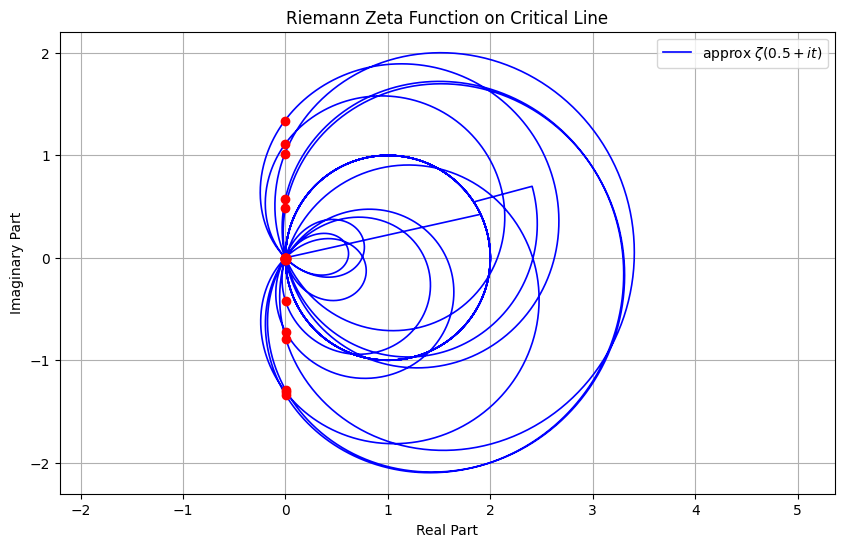

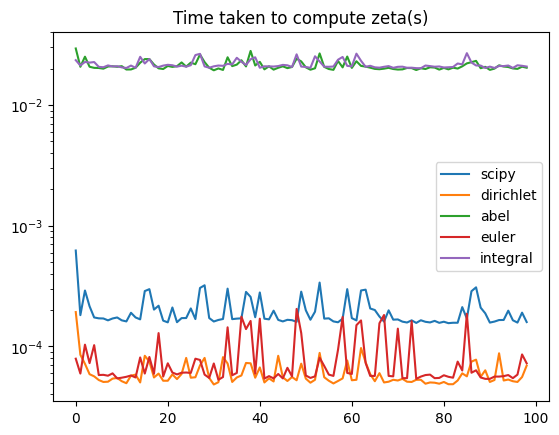

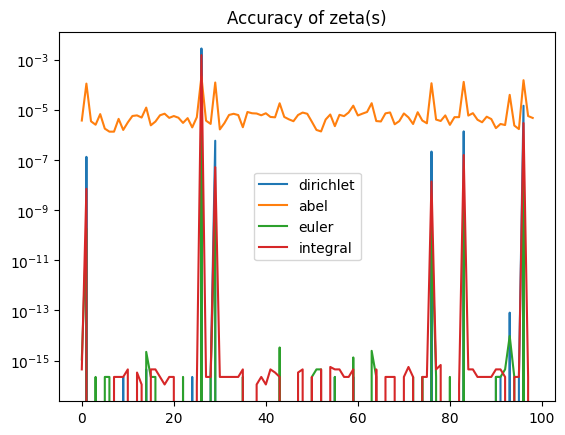

In [16]:
import numpy as np
import math 
def eta(s,n=1000):
    """
    s is a complex number with real part greater than 0.
    Returns the value of the Dirichlet eta function at s.
    """

    if not isinstance(s, complex) and np.isreal(s):
        s = complex(s)
    elif s.real <= 0:
        raise(ValueError,"s must be real or complex number with real part greater than 0")
    ns = np.arange(1, n + 1)
    terms = (-1)**(ns - 1) / (ns**s)  
    return np.sum(terms)
    
def zeta_dirichlet(s,n=1000):
    """
    s is a complex number with real part greater than 0.
    Zeta via relation to Eta: ζ(s) = η(s) / (1 - 2^(1-s)), valid for Re(s) > 0, s ≠ 1
    Returns the value of the Riemann zeta function at s.
    """
    if np.abs(s-1)<1e-10:
        return float("inf")
    if np.abs(s)<1e-10:
        return -0.5
    elif s.real >1 :
        a = np.sum(1.0/np.arange(1,n+1)**s)
        return a
    elif 0<s.real<1:
        return eta(s,n)/(1-np.pow(2,1-s))
    else:
        raise(ValueError,"s must be real or complex number with real part greater than 0")

def zeta_euler(s,n=1000):
    """
    s is a complex number with real part greater than 0.
    Euler Product: ζ(s) = ∏(1 - p^(-s))^{-1}, valid only for Re(s) > 1
    Returns the value of the Riemann zeta function at s.
    """
    if np.abs(s-1)<1e-10:
        return float("inf")
    if np.abs(s)<1e-10:
        return -0.5
    elif s.real >1 :
        a = np.prod(1/(1-primes[:n]**(-s)))
        return a
    elif 0<s.real<1:
        return eta(s,n)/(1-np.pow(2,1-s))
    else:
        raise(ValueError,"s must be real or complex number with real part greater than 0")

def zeta_hadamard(s):
    raise(NotImplementedError("Not implemented yet"))

def zeta_integral(s, x_max=1000):
    """
    s is a complex number with real part greater than 0.
    Integral representation of zeta function:
    ζ(s) = 1/Γ(s) ∫₀^∞ x^{s-1}/(e^x - 1) dx
    Uses trapezoidal rule from 0 to x_max.
    Returns the value of the Riemann zeta function at s.
    """
    n = int(x_max)**2
    if np.abs(s-1)<1e-10:
        return float("inf")
    if np.abs(s)<1e-10:
        return -0.5
    elif 0<s.real<1:
        return eta(s,n)/(1-np.pow(2,1-s))
    
    if s.real <= 0:
        raise ValueError("Integral method not valid for Re(s) ≤ 0")

    x = np.linspace(1e-6, x_max, n)  # Avoid division by zero at x=0
    integrand = (x**(s - 1)) / (np.exp(x) - 1)
    integral = np.trapz(integrand, x)
    return integral / math.gamma(s)

def zeta_abel(s,n=1000):
    """
    s is a complex number with real part greater than 0.
    Returns the value of the Riemann zeta function at s.
    """
    if np.abs(s-1)<1e-10:
        return float("inf")
    if np.abs(s)<1e-10:
        return -0.5
    elif 0<s.real<1:
        return eta(s,n)/(1-np.pow(2,1-s))
    elif s.real >1 :
        x = np.linspace(1e-6, n, n**2)
        integrand = (np.floor(x) - x) / (x + 1.0)**(s + 1)
        integral = np.trapz(integrand, x)
        return 1.0 / (s - 1) + 1.0 + s * integral
    else:
        raise(ValueError,"s must be real or complex number with real part greater than 0")

from scipy.special import gamma, loggamma

def theta(t):
    """Implements the Riemann-Siegel theta function."""
    s = 0.5 + 1j * t
    # Using the identity: theta(t) = arg(gamma((s)/2) * pi^(-s/2))
    return (np.imag(loggamma(s / 2)) - (s / 2) * np.log(np.pi)).real

def riemann_siegel_sum(t, N=None):
    """Computes the main Riemann-Siegel sum."""
    if N is None:
        N = int(np.floor(np.sqrt(t / (2 * np.pi))))
    
    n = np.arange(1, N + 1)
    cos_term = np.cos(theta(t) - t * np.log(n))
    return 2 * np.sum(cos_term / np.sqrt(n))

def Z(t):
    """Hardy Z-function using Riemann-Siegel approximation."""
    return riemann_siegel_sum(t)

def zeta_critical_line(t):
    """Returns ζ(0.5 + it) using Hardy Z-function and theta."""
    z = Z(t)
    th = theta(t)
    return z * np.exp(-1j * th)

# Generate values of t
t_values = np.linspace(0, 50, 10000)

# Compute zeta values on critical line
zeta_values = np.zeros_like(t_values, dtype=complex)
for i, t in enumerate(t_values):
    zeta_values[i] = zeta_critical_line(t)

# Plot real vs imaginary parts
plt.figure(figsize=(10,6))
plt.plot(zeta_values.real, zeta_values.imag, lw=1.2, color='blue', label=r"approx $\zeta(0.5 + it)$")

# Highlight approximate zero crossings
zero_indices = np.where(np.diff(np.sign(zeta_values.real)))[0]
for idx in zero_indices:
    plt.plot(zeta_values[idx].real, zeta_values[idx].imag, 'ro')

plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.title("Riemann Zeta Function on Critical Line")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()


time_zeta_scipy = []
time_zeta_dirichlet = []
time_zeta_abel = []
time_zeta_euler = []
time_zeta_integral = []
accuracy_zeta_dirichlet = []
accuracy_zeta_abel = []
accuracy_zeta_euler = []
accuracy_zeta_integral = []
for i in range(1,100):
    s = np.random.uniform(0,100)
    start = time.time()
    true_value = zeta(s)
    end = time.time()
    time_zeta_scipy.append(end-start)
    start = time.time()
    dirichlet_value = zeta_dirichlet(s)
    end = time.time()
    time_zeta_dirichlet.append(end-start)
    accuracy_zeta_dirichlet.append(np.abs(true_value-dirichlet_value))
    start = time.time()
    abel_value = zeta_abel(s)
    end = time.time()
    time_zeta_abel.append(end-start)
    accuracy_zeta_abel.append(np.abs(true_value-abel_value))
    start = time.time()
    euler_value = zeta_euler(s)
    end = time.time()
    time_zeta_euler.append(end-start)
    accuracy_zeta_euler.append(np.abs(true_value-euler_value))
    start = time.time()
    integral_value = zeta_integral(s)
    end = time.time()
    time_zeta_integral.append(end-start)
    accuracy_zeta_integral.append(np.abs(true_value-integral_value))
import matplotlib.pyplot as plt 
plt.plot(time_zeta_scipy,label = "scipy")
plt.plot(time_zeta_dirichlet,label = "dirichlet")
plt.plot(time_zeta_abel,label = "abel")
plt.plot(time_zeta_euler,label = "euler")
plt.plot(time_zeta_integral,label = "integral")
plt.yscale("log")
plt.legend()
plt.title("Time taken to compute zeta(s)")
plt.show()

plt.plot(accuracy_zeta_dirichlet,label = "dirichlet")

plt.plot(accuracy_zeta_abel,label = "abel")
plt.plot(accuracy_zeta_euler,label = "euler")
plt.plot(accuracy_zeta_integral,label = "integral")
plt.yscale("log")
plt.legend()
plt.title("Accuracy of zeta(s)")
plt.show()


# Gamma Function 
1. Definition: The Gamma function is defined as: $\Gamma(s) =\int_0^\infty t^{s-1}e^{-t}dt$, where s is a complex number with a positive real part.
2. Properties: The Gamma function is a generalization of the factorial function to complex numbers. It satisfies the functional equation $\Gamma(s+1) = s\Gamma(s)$ and has poles at the non-positive integers.
3. Applications: The Gamma function is used in many areas of mathematics and physics, including probability theory, statistics, and quantum mechanics.
4. Computation: The Gamma function can be computed using various methods, including the Lanczos approximation, the Stirling approximation, and the Weierstrass product.
5. Special Values: The Gamma function has special values at certain points, such as $\Gamma(1) = 1$ and $\Gamma(1/2) = \sqrt\pi$.

6. Computing the Gamma function:
- For $\Re(z)>0$:
$$\Gamma(z) = \int_0^\infty t^{z-1}e^{-t}dt$$
- Relation to other function:  
Reccurence: $\Gamma(z+1)=s\Gamma(z)$, Generalized version of factorials: $\Gamma(n)=(n-1)!$, Relation to Beta function: $\Beta(x,y)=\frac{\Gamma(x)\Gamma(y)}{\Gamma(x+y)}$, Reflection formula: $\Gamma(z)\Gamma(1-z)=\frac{\pi}{\sin(\pi z)}$, special value: $\Gamma(1/2)=\sqrt{\pi}$
- Limit approximation and Infinite product: 

$$\Gamma(z) = \lim_{n \to \infty} \frac{n!n^z}{z(z+1)\cdots(z+n)}$$
$$\Gamma(z) = \frac{1}{s} \prod_{n=1}^\infty \frac{(1+\frac{1}{n})^z}{1+\frac{z}{n}}$$
- Stirling's approximation:
$$\Gamma(z) \sim \sqrt{\frac{2\pi}{z}}\left(\frac{z}{e}\right)^z \quad (|z| \to \infty, |\arg z| < \pi)$$
- Euler's reflection formula:
$$\Gamma(z)\Gamma(1-z) = \frac{\pi}{\sin \pi z}$$
- Legendre's duplication formula:
$$\Gamma(z)\Gamma(z+\frac{1}{2}) = 2^{1-2z}\sqrt{\pi}\Gamma(2z)$$
- Gauss's multiplication formula:
$$\Gamma(nz) = (2\pi)^{(1-n)/2} n^{nz-1/2} \prod_{k=0}^{n-1} \Gamma\left(z+\frac{k}{n}\right)$$
- Weierstrass's product formula:
$$\frac{1}{\Gamma(z)} = ze^{\gamma z} \prod_{n=1}^{\infty} \left(1+\frac{z}{n}\right)e^{-z/n}$$
- Barnes's G-function:
$$G(1+z) = (2\pi)^{z/2} \Gamma(z+1)$$
- Barnes's double gamma function:
$$\Gamma(z+1) = \frac{\Gamma_{2}(z+1)}{\Gamma_{2}(z)}$$


In [23]:
from scipy.integrate import quad
from scipy.special import bernoulli 
def gamma_integral(z):
    """
    z is a complex number, and return the gamma(z) using the integral formula:
    $$\Gamma(z) = \int_{0}^{\infty} t^{z-1} e^{-t} dt$$
    """
    x2 = lambda t: t**(z-1)*np.exp(-t)
    z = complex(z)
    if z.real<0:
        raise(ValueError,"z must be positive")
    return quad(x2,0,np.inf)[0]
    

def gamma_stirling(z,order=2):
    """ 
    z is a complex number, and return the gamma(z) using the stirling formula:
    $$\Gamma(z) = \sqrt{2\pi} z^{z-1/2} e^{-z} \sum_{n=0}^{\infty} \frac{B_{2n}}{2n(2n-1)z^{2n-1}}$$
    """
    z = complex(z)
    
    if z.real<0:
        raise(ValueError,"z must be positive")
    return np.sqrt(2*np.pi)*z**(z-1/2)*np.exp(-z)*sum([bernoulli(2*n)/(2*n*(2*n-1)*z**(2*n-1)) for n in range(order)])
    



In [24]:
gamma_stirling(10)

array([nan+nanj, nan+nanj, nan+nanj])